# ER Diagram

<!-- <img src="er_diagram.png" alt="ER diagram" width="400" height="200">
<p align="center"><img src="image.png" alt="Centered image"></p> -->

The ER diagram does not include everything, it includes the most common subset used. Full description at https://aisynphys.readthedocs.io/en/current-release/api_schema.html#api-schema

![ER Diagram](er_diagram.png "ER diagram")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd
import pyqtgraph
print(pyqtgraph.__file__)
import neuroanalysis
print(neuroanalysis.__file__)
import neuroanalysis.util
import aisynphys
import aisynphys.database
print(aisynphys.__file__)

from IPython.display import display, Markdown

c:\Users\snrambo\AppData\Local\miniconda3\envs\aisynphys39\lib\site-packages\pyqtgraph\__init__.py
C:\Users\snrambo\neuroanalysis\neuroanalysis\__init__.py
C:\Users\snrambo\aisynphys\aisynphys\__init__.py


# Set up DB connection

To get this working, I have:
* Downloaded aisynphys source code
* Downloaded neuroanalysis source code
* Set up environment in anaconda, with python 3.9:

```powershell
# clone repo aisynphys
# change to python 3.9 in yaml
mamba create -n aisynphys39 python=3.9
conda activate aisynphys39
mamba install numpy scipy pandas matplotlib sqlalchemy pyqt pyqtgraph numba h5py -c conda-forge
pip install lmfit
cd C:\Users\myuser\src\aisynphys
python setup.py develop
# cd to user
git clone https://github.com/alleninstitute/neuroanalysis
cd C:\Users\myuser\neuroanalysis
python setup.py develop
# Then was a problem with missing pyyaml, so downloaded that
mamba install -c conda-forge pyyaml
```

In [3]:
from aisynphys.database import SynphysDatabase # https://aisynphys.readthedocs.io/en/current-release/database_access.html#database-access
from pathlib import Path

# Define cache directory
CACHE_PATH = Path("data/aisynphys/cache").resolve()

# Create a cache directory if it does not exist
CACHE_PATH.mkdir(parents=True, exist_ok=True)

# Tell AISynPhys to use this cache
aisynphys.config.cache_path = CACHE_PATH
# SynphysDatabase.set_cache_path(CACHE_PATH)


# Make cache
DATA_ROOT = Path("data/aisynphys/cache")

# Inspect available database versions
SynphysDatabase.list_versions()  # List all available versions

# Load small database -- Uncomment to load
# DB_VERSION = 'synphys_r2.1_medium.sqlite'
# db = SynphysDatabase.load_version(DB_VERSION)

[{'db_file': 'synphys_r1.0_2019-08-29_small.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_small.sqlite',
  'schema_version': '15',
  'release_version': '1.0',
  'db_size': 'small'},
 {'db_file': 'synphys_r1.0_small.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_small.sqlite',
  'schema_version': '15',
  'release_version': '1.0',
  'db_size': 'small'},
 {'db_file': 'synphys_r1.0_2019-08-29_medium.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_medium.sqlite',
  'schema_version': '15',
  'release_version': '1.0',
  'db_size': 'medium'},
 {'db_file': 'synphys_r1.0_medium.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_medium.sqlite',
  'schema_version': '15',
  'release_version': '1.0',
  'db_size': 'medium'},
 {'db_file': 'synphys_r1.0_2019-08-29_full.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_full.sqlite',
  'schema_

In [4]:
# Get file path and ensure it exist
DB_PATH = Path('data/aisynphys/cache/database/synphys_r2.1_medium.sqlite').resolve()  # database

assert DB_PATH.exists(), f"Database file not found: {DB_PATH}"

In [5]:
# Create SQLite connection to SQLite database

con = sqlite3.connect(DB_PATH)  # Create a connection object that "connects to the database"
cur = con.cursor()  # database cursor

Ta med:

* Neuron gain (low, medium, high). Gain = slope of F/I curve? Knyttet til nevron ID
* Heterogeneity --> One network naturally is

https://neuronaldynamics.epfl.ch/online/Ch13.S6.html

https://neuronaldynamics.epfl.ch/online/Ch12.S4.html 




# Table overview

In [6]:
table_list = cur.execute(
    "SELECT name FROM sqlite_master WHERE type='table'"
).fetchall()

for i, name in enumerate(table_list):
    print(i, name[0])


# Because they are stored in the form of ('pair',), accessing them by (str(list[i])[2:-3]) displays from the third index which is the first letter (excluding "('" ), and excluding the last "',)"
print(f"{str(table_list[9])[2:-3]}\n{str(table_list[20])[2:-3]}")

0 metadata
1 pipeline
2 slice
3 experiment
4 electrode
5 sync_rec
6 cortical_site
7 cell
8 recording
9 pair
10 intrinsic
11 morphology
12 test_pulse
13 stim_pulse
14 baseline
15 cortical_cell_location
16 patch_seq
17 patch_clamp_recording
18 stim_spike
19 pulse_response
20 synapse
21 poly_synapse
22 dynamics
23 synapse_prediction
24 gap_junction
25 synapse_model
26 multi_patch_probe
27 avg_response_fit
28 pulse_response_fit
29 pulse_response_strength
30 resting_state_fit
31 conductance
pair
synapse


In [22]:
query = """
            SELECT fi_slope FROM intrinsic
            WHERE fi_slope IS NOT NULL
            ORDER BY fi_slope DESC
            ;
        """

df = pd.read_sql_query(query, con)

df

,fi_slope
0,3.894356e-11
1,3.199994e-11
2,5.871778e-12
3,5.325688e-12
4,5.300000e-12
...,...
4614,-1.073825e-12
4615,-1.267327e-12
4616,-1.350000e-12
4617,-1.199993e-11


In [11]:
slope_vals = cur.execute("""SELECT MAX(fi_slope), MIN(fi_slope), AVG(fi_slope) FROM intrinsic""").fetchall()

print(slope_vals[0])

(3.8943561546762944e-11, -3.20000305176071e-11, 3.5902876328371054e-13)


In [23]:
query = """
            SELECT * FROM synapse
        """

df = pd.read_sql_query(query, con)

df

,id,pair_id,synapse_type,latency,psp_amplitude,psp_rise_time,psp_decay_tau,psc_amplitude,psc_rise_time,psc_decay_tau,meta
0,1,88744,ex,0.001527,NaN,NaN,NaN,-8.184031e-12,0.001620,0.005693,null
1,2,119060,ex,0.002883,0.000014,0.006833,0.064710,NaN,NaN,NaN,null
2,3,30118,ex,0.001915,0.000953,0.003041,0.021771,-1.694641e-11,0.001565,0.004934,null
3,4,121773,in,0.000861,NaN,NaN,NaN,2.778897e-12,0.000817,0.003067,null
4,5,56173,in,0.001513,NaN,NaN,NaN,1.054188e-12,0.000933,0.004090,null
...,...,...,...,...,...,...,...,...,...,...,...
3292,3666,81802,ex,0.001381,0.000031,0.003111,0.015602,NaN,NaN,NaN,null
3293,3667,81804,ex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null
3294,3668,81806,ex,0.002304,0.000271,0.002189,0.010108,NaN,NaN,NaN,null
3295,3669,81816,ex,0.000848,0.001185,0.003383,0.020394,-3.026264e-11,0.001633,0.009829,null


# Formatting for figures

In [8]:
plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 14,                  # Base size 8-12 pt
    # Axes
    "axes.titlesize": 18,             # Axis title size
    "axes.labelsize": 18,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles
    # Ticks
    "xtick.labelsize": 18,             # X tick label size (8-12)
    "ytick.labelsize": 16,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction
    # Legends
    "legend.fontsize": 16,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location
    # Resolution
    # "figure.dpi": 500,                # Display DPI  UNCOMMENT LATER. I commented it out now while I work on it, because Jupyter displayed pixel size = figsize * figure.dpi, causing huge images now in the notebook
    "figure.dpi": 100,
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace
    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif
    # Make text editable in Inkscape
    "svg.fonttype": 'none',
})

In [8]:
query = """
            SELECT DISTINCT target_region FROM experiment
        """

df = pd.read_sql_query(query, con)

df

,target_region
0,VisP
1,ALM
2,TCx
3,FCx
4,None
5,
6,PCx
7,TEa
8,ACC
9,OCx



VisP: Primary Visual Cortex
ALM: Anterior Lateral Motor Cortex
TCx: Temporal Cortex
FCx: Frontal Cortex
None
  (empty):
PCx: Piriform Cortex
TEa: Temporal Association Area
ACC: Anterior Cingulate Cortex
OCx: Occipital Cortex

TODO
* Clean data: Only include relevant 
    * Mouse
    * Target region_ VisP
    * Pairs in this


# Queries that might be used a lot

The reason my query returned less rows than the old code is because in the old code, it is not using the requirement that species is mouse and target_region is VisP. The WHERE filtering I apply in the query for valid experiments includes this and it gives 37121  rows (with 2441 unique experiments). If I comment out those filters, it becomes 40671. I am writing this in case we decide to use this filter.

In [9]:
df = pd.read_sql_query(
    # "SELECT COUNT(DISTINCT id) FROM pair;"
    "SELECT * FROM pair LIMIT 4"
    , con)
df

,id,experiment_id,pre_cell_id,post_cell_id,has_synapse,has_polysynapse,has_electrical,crosstalk_artifact,n_ex_test_spikes,n_in_test_spikes,distance,lateral_distance,vertical_distance,reciprocal_id,meta
0,1,1,1,2,None,None,None,None,0,0,None,None,None,17,null
1,2,2,3,7,None,None,None,None,0,0,None,None,None,13,null
2,3,2,3,9,None,None,None,None,0,0,None,None,None,24,null
3,4,1,1,4,None,None,None,None,0,0,None,None,None,32,null


In [10]:
df = pd.read_sql_query("SELECT * FROM cell LIMIT 4", con)
df

,id,experiment_id,ext_id,electrode_id,cre_type,target_layer,position,depth,cell_class,cell_class_nonsynaptic,meta
0,1,1,1,1,unknown,,null,None,None,None,"{""lims_specimen_id"": null, ""transgenic_cell_cl..."
1,2,1,2,2,unknown,,null,None,None,None,"{""lims_specimen_id"": null, ""transgenic_cell_cl..."
2,3,2,2,9,unknown,,null,None,None,None,"{""lims_specimen_id"": null, ""transgenic_cell_cl..."
3,4,1,3,3,unknown,,null,None,None,None,"{""lims_specimen_id"": null, ""transgenic_cell_cl..."


## Valid experiments

In this, we find cell pairs that:

* Belong to an experiment
* Belong to a mouse slice
* Experiment targets VisP 
* Both cells exist
* Both cell classes are known
* Presynaptic cell is not mixed

In [11]:
# df_slice = pd.read_sql_query("SELECT mouse_id FROM slice  WHERE species = 'mouse'", con)  # IDs of mouse
# df_experiment_ids = pd.read_sql_query("SELECT id AS exp_id FROM experiment WHERE target_region = 'VisP'", con)  # IDs of experiments in Primary Visual Cortex
# df_cell = pd.read_sql_query("SELECT * FROM cell", con)
# df_pair = pd.read_sql_query("SELECT * FROM pair", con)

df = pd.read_sql_query("SELECT DISTINCT cell_class from cell", con)
df

,cell_class
0,None
1,ex
2,in
3,mixed


### Query to get valid experiment

In [106]:
import os
print(os.getcwd())

c:\Users\snrambo\Projects\NEVR3901\HeterogenousRNN\HeterogeneousRNNs\data_analysis


Since we will be including neuronal gain, I keep only those that have measured fi_slope. It reduces number of data points. Without, it is 37171 rows, and with it is 7691 (unless we also filter by number of pairs). Additionally, I do left join with synapse so we get synapse data when there was a synapse

In [107]:
## Here I show that for each unique cell ID, there is one measured fi slope


query = """ 
        -- --------------------------------------------------------------
        --  FI slope for every cell (one row per cell)
        -- --------------------------------------------------------------
        SELECT
            c.id                AS cell_id,          -- primary key of the cell
            c.cell_class        AS cell_class,       -- cell class
            i.fi_slope          AS fi_slope         -- fi_slope
        FROM
            cell      AS c
        INNER JOIN
            intrinsic AS i
            ON c.id = i.cell_id               -- match cell ↔ intrinsic record
        WHERE
            i.fi_slope IS NOT NULL            -- drop rows where the slope wasnt measured
        ORDER BY
            c.id;

        """

cell_intrinsics = pd.read_sql_query(query, con)

print(len(cell_intrinsics['cell_id'].unique()))
cell_intrinsics



4619


,cell_id,cell_class,fi_slope
0,3131,in,2.666342e-13
1,3137,ex,2.226355e-14
2,3138,in,3.086337e-13
3,3139,ex,1.764603e-14
4,3140,ex,2.527907e-14
...,...,...,...
4614,24791,in,4.244768e-13
4615,24798,mixed,3.932555e-13
4616,24799,in,5.590663e-13
4617,24813,ex,7.079645e-14


In [108]:
# PSP amplitude to synapse
# Since in synapse table there is only relations when there was a synapse (has_synapse=1), I loose those where there was not a synapse when joining. So need left join

query = """ 
            SELECT 
                p.experiment_id,
                p.pre_cell_id, 
                p.post_cell_id, 
                p.has_synapse, 

                -- Synapse things are masked when there is no synapse 
                syn.id AS synapse_id, 
                syn.psp_amplitude,

                -- Cell class and F/I slope
                pre.cell_class  AS pre_cell_class,
                post.cell_class AS post_cell_class,
                i_pre.fi_slope  AS fi_slope_pre,
                i_post.fi_slope AS fi_slope_post

            FROM pair p

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id
            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
            LEFT JOIN synapse syn ON syn.pair_id = p.id  -- pair --> synapse

            WHERE 
                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL

                AND i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL

                AND pre.cell_class != 'mixed'
                ; 
"""

df_valid_experiments = pd.read_sql_query(query, con)

df_valid_experiments

,experiment_id,pre_cell_id,post_cell_id,has_synapse,synapse_id,psp_amplitude,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post
0,600,4133,4138,0,NaN,NaN,in,in,8.230065e-13,1.105000e-12
1,600,4133,4140,0,NaN,NaN,in,ex,8.230065e-13,1.131452e-13
2,600,4133,4142,0,NaN,NaN,in,in,8.230065e-13,8.820777e-13
3,600,4138,4133,0,NaN,NaN,in,in,1.105000e-12,8.230065e-13
4,600,4138,4140,1,1895.0,-0.000204,in,ex,1.105000e-12,1.131452e-13
...,...,...,...,...,...,...,...,...,...,...
7686,5108,24790,24791,1,3384.0,NaN,ex,in,6.639170e-14,4.244768e-13
7687,5108,24791,24790,1,3391.0,-0.000314,in,ex,4.244768e-13,6.639170e-14
7688,5110,24799,24798,0,NaN,NaN,in,mixed,5.590663e-13,3.932555e-13
7689,5117,24813,24814,1,3374.0,0.000379,ex,in,7.079645e-14,7.336674e-13


In [109]:

# There is only one PSP amplitude associated with a synapse


query = """ 
SELECT
    pair_id,
    COUNT(*) AS n_synapses
FROM synapse
GROUP BY pair_id
HAVING COUNT(*) > 1
ORDER BY n_synapses DESC;
"""

df = pd.read_sql_query(query, con)

df

,pair_id,n_synapses


The query below filters the data we want, separates F/I slope into categories (low, medium, high) using mean and std $\sigma=\frac{\sum(x-\mu)^2}{n-1}$, and it is parameterized so we can choose only experiments containing a certain number of pairs. 

In [117]:
# Divide fi slope into low, medium, high
# Parameterized so that we dont have to change the query each time

min_total_pairs = 0
params = {"min_total_pairs": min_total_pairs}
print(f"Included {min_total_pairs} pairs")

query = """ 

-- Whitelist - experiments that have at least :min_total_pairs

WITH exp_total AS (
    SELECT
        p.experiment_id,
        COUNT(*) AS total_pairs
    FROM pair p
    JOIN cell       pre   ON p.pre_cell_id  = pre.id   AND pre.cell_class IS NOT NULL
    JOIN cell       post  ON p.post_cell_id = post.id  AND post.cell_class IS NOT NULL
    JOIN intrinsic  i_pre ON p.pre_cell_id  = i_pre.cell_id  AND i_pre.fi_slope IS NOT NULL
    JOIN intrinsic  i_post ON p.post_cell_id = i_post.cell_id AND i_post.fi_slope IS NOT NULL
    JOIN experiment e    ON e.id = p.experiment_id
    JOIN slice      s    ON e.slice_id = s.id
    WHERE
        s.species        = 'mouse'
        AND e.target_region = 'VisP'
        AND p.has_synapse IS NOT NULL
        AND pre.cell_class != 'mixed'
        AND i_pre.fi_slope IS NOT NULL
        AND i_post.fi_slope IS NOT NULL
    GROUP BY p.experiment_id
    HAVING COUNT(*) >= :min_total_pairs       -- this is a parameter that can be set in python
),

-- Sample statistics for pre- and post-cells

stats AS (
    SELECT
        /* ----- pre‑synaptic ----- */
        AVG(i_pre.fi_slope)                     AS pre_mu,
        COUNT(i_pre.fi_slope)                   AS pre_n,
        SUM(i_pre.fi_slope)                     AS pre_sum,
        SUM(i_pre.fi_slope * i_pre.fi_slope)    AS pre_sum_sq,

        /* ----- post‑synaptic ----- */
        AVG(i_post.fi_slope)                    AS post_mu,
        COUNT(i_post.fi_slope)                  AS post_n,
        SUM(i_post.fi_slope)                    AS post_sum,
        SUM(i_post.fi_slope * i_post.fi_slope)  AS post_sum_sq
    FROM pair        AS p
    JOIN intrinsic   AS i_pre  ON p.pre_cell_id  = i_pre.cell_id
    JOIN intrinsic   AS i_post ON p.post_cell_id = i_post.cell_id
    JOIN experiment  AS e      ON e.id = p.experiment_id
    JOIN slice       AS s      ON e.slice_id = s.id
    WHERE
        s.species        = 'mouse'
        AND e.target_region = 'VisP'
        AND i_pre.fi_slope IS NOT NULL
        AND i_post.fi_slope IS NOT NULL
),

stats_with_sigma AS (
    SELECT
        pre_mu,
        post_mu,
        SQRT( (pre_sum_sq - (pre_sum * pre_sum) / pre_n) / (pre_n - 1) )   AS pre_sigma,
        SQRT( (post_sum_sq - (post_sum * post_sum) / post_n) / (post_n - 1) ) AS post_sigma
    FROM stats
),

-- Detailed rows: The full dataframe 

detailed AS (
    SELECT
        p.experiment_id,
        p.pre_cell_id,
        p.post_cell_id,
        p.has_synapse,
        pre.cell_class   AS pre_cell_class,
        post.cell_class  AS post_cell_class,
        i_pre.fi_slope   AS fi_slope_pre,
        i_post.fi_slope  AS fi_slope_post,

        /* ---- FI‑categories (same as your original query) ---- */
        CASE
            WHEN i_pre.fi_slope < s.pre_mu - s.pre_sigma THEN 'small'
            WHEN i_pre.fi_slope > s.pre_mu + s.pre_sigma THEN 'high'
            ELSE 'medium'
        END AS pre_fi_category,

        CASE
            WHEN i_post.fi_slope < s.post_mu - s.post_sigma THEN 'small'
            WHEN i_post.fi_slope > s.post_mu + s.post_sigma THEN 'high'
            ELSE 'medium'
        END AS post_fi_category,

        /* ---- PSP amplitude -------------------------------------------------
           * Keep the amplitude only when a synapse really exists
           * (has_synapse = 1). Otherwise return NULL → pandas will show NaN.
           ------------------------------------------------------------------- */
        CASE
            WHEN p.has_synapse = 1 THEN syn.psp_amplitude
            ELSE NULL
        END AS psp_amplitude,

        /* Optional: keep the synapse primary‑key for reference */
        syn.id AS synapse_id
    FROM pair       AS p
    JOIN cell       AS pre   ON p.pre_cell_id  = pre.id   AND pre.cell_class IS NOT NULL
    JOIN cell       AS post  ON p.post_cell_id = post.id  AND post.cell_class IS NOT NULL
    JOIN intrinsic  AS i_pre ON p.pre_cell_id  = i_pre.cell_id  AND i_pre.fi_slope IS NOT NULL
    JOIN intrinsic  AS i_post ON p.post_cell_id = i_post.cell_id AND i_post.fi_slope IS NOT NULL
    JOIN experiment AS e     ON e.id = p.experiment_id
    JOIN slice      AS s     ON e.slice_id = s.id
    LEFT JOIN synapse AS syn   ON syn.pair_id = p.id                -- one‑to‑one (or none)
    CROSS JOIN stats_with_sigma s
    WHERE
        s.species        = 'mouse'
        AND e.target_region = 'VisP'
        AND pre.cell_class != 'mixed'
           --This filter is present in Query 1 – it must be kept so that the two result sets have the same base rows.
        AND p.has_synapse IS NOT NULL

        -- optional:
        AND p.experiment_id IN (SELECT experiment_id FROM exp_total)
)


-- Final output: – attach the global μ / σ values to every row for convenience

SELECT
    d.*,
    sws.pre_mu,
    sws.pre_sigma,
    sws.post_mu,
    sws.post_sigma
FROM detailed d
CROSS JOIN stats_with_sigma sws
ORDER BY d.experiment_id, d.pre_cell_id, d.post_cell_id;

        """

main_df = pd.read_sql_query(query, con, params=params)
df = main_df.copy()

print(f"There were {df['experiment_id'].nunique()} unique experiments")  # unique experiments
print(df['pre_fi_category'].value_counts())
print(df['post_fi_category'].value_counts())
print(f"There are {len(df['experiment_id'])} rows when we include at least {min_total_pairs} pairs")

main_df



Included 0 pairs
There were 872 unique experiments
pre_fi_category
medium    7002
high       620
small       69
Name: count, dtype: int64
post_fi_category
medium    7002
high       613
small       76
Name: count, dtype: int64
There are 7691 rows when we include at least 0 pairs


,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,pre_fi_category,post_fi_category,psp_amplitude,synapse_id,pre_mu,pre_sigma,post_mu,post_sigma
0,600,4133,4138,0,in,in,8.230065e-13,1.105000e-12,medium,high,NaN,NaN,4.054656e-13,6.913182e-13,4.054656e-13,6.913182e-13
1,600,4133,4140,0,in,ex,8.230065e-13,1.131452e-13,medium,medium,NaN,NaN,4.054656e-13,6.913182e-13,4.054656e-13,6.913182e-13
2,600,4133,4142,0,in,in,8.230065e-13,8.820777e-13,medium,medium,NaN,NaN,4.054656e-13,6.913182e-13,4.054656e-13,6.913182e-13
3,600,4138,4133,0,in,in,1.105000e-12,8.230065e-13,high,medium,NaN,NaN,4.054656e-13,6.913182e-13,4.054656e-13,6.913182e-13
4,600,4138,4140,1,in,ex,1.105000e-12,1.131452e-13,high,medium,-0.000204,1895.0,4.054656e-13,6.913182e-13,4.054656e-13,6.913182e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7686,5108,24790,24791,1,ex,in,6.639170e-14,4.244768e-13,medium,medium,NaN,3384.0,4.054656e-13,6.913182e-13,4.054656e-13,6.913182e-13
7687,5108,24791,24790,1,in,ex,4.244768e-13,6.639170e-14,medium,medium,-0.000314,3391.0,4.054656e-13,6.913182e-13,4.054656e-13,6.913182e-13
7688,5110,24799,24798,0,in,mixed,5.590663e-13,3.932555e-13,medium,medium,NaN,NaN,4.054656e-13,6.913182e-13,4.054656e-13,6.913182e-13
7689,5117,24813,24814,1,ex,in,7.079645e-14,7.336674e-13,medium,medium,0.000379,3374.0,4.054656e-13,6.913182e-13,4.054656e-13,6.913182e-13


### Other queries

In [ ]:
# Synapse count

query = """ 
            SELECT 
                p.experiment_id,
                COUNT(*) AS total_pairs,
                SUM(CASE WHEN p.has_synapse = 1 THEN 1 ELSE 0 END) AS num_synapses,
                COUNT(*) - SUM(CASE WHEN p.has_synapse = 1 THEN 1 ELSE 0 END) AS num_no_synapses


            FROM pair p

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id
            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
            --LEFT JOIN synapse syn ON syn.pair_id = p.id  -- pair --> synapse


            WHERE 
                s.species = 'mouse' 
                AND e.target_region = 'VisP' 
                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL
                AND i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL
                AND pre.cell_class != 'mixed'
                
            GROUP BY p.experiment_id
            HAVING total_pairs >= 2  -- comment if keeping all
            ;
        """

df_num_synapses = pd.read_sql_query(query, con)

df_num_synapses

df = df_num_synapses.copy()
df
# experiments = (df['experiment_id'].unique())

,experiment_id,total_pairs,num_synapses,num_no_synapses
0,600,12,2,10
1,605,6,1,5
2,606,6,0,6
3,610,6,1,5
4,611,2,0,2
...,...,...,...,...
842,5006,6,3,3
843,5011,2,0,2
844,5022,6,2,4
845,5108,2,2,0


In [ ]:
# Get only unique ids

# Data structure to store motifs

# Valid experiment ids

cur.execute("""
    SELECT DISTINCT p.experiment_id FROM pair p
    INNER JOIN cell pre ON p.pre_cell_id = pre.id
    INNER JOIN cell post ON p.post_cell_id = post.id
    INNER JOIN experiment e ON e.id = p.experiment_id
    INNER JOIN slice s ON e.slice_id = s.id

    WHERE 

        -- Brain specs
        s.species = 'mouse' 
        AND e.target_region = 'VisP' 

        -- Requirements on data
        AND p.has_synapse IS NOT NULL
        AND pre.cell_class IS NOT NULL
        AND post.cell_class IS NOT NULL

        -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
        AND pre.cell_class != 'mixed'; 
    """)

experiment_ids = cur.fetchall()

print(experiment_ids)
print(len(experiment_ids))


[(25,), (35,), (36,), (38,), (39,), (40,), (44,), (46,), (49,), (52,), (53,), (54,), (57,), (59,), (61,), (63,), (64,), (65,), (66,), (67,), (73,), (78,), (79,), (80,), (81,), (82,), (85,), (86,), (87,), (89,), (96,), (97,), (98,), (99,), (103,), (104,), (106,), (108,), (110,), (113,), (117,), (119,), (122,), (134,), (137,), (143,), (144,), (145,), (152,), (153,), (155,), (160,), (162,), (163,), (164,), (165,), (168,), (169,), (170,), (171,), (174,), (177,), (179,), (182,), (184,), (185,), (186,), (188,), (194,), (195,), (196,), (197,), (198,), (199,), (200,), (201,), (202,), (205,), (207,), (210,), (213,), (215,), (219,), (221,), (223,), (225,), (226,), (230,), (233,), (235,), (236,), (241,), (243,), (244,), (245,), (247,), (248,), (249,), (250,), (253,), (254,), (255,), (256,), (257,), (259,), (260,), (261,), (263,), (264,), (267,), (269,), (270,), (271,), (273,), (274,), (277,), (278,), (279,), (280,), (283,), (284,), (287,), (288,), (289,), (290,), (291,), (292,), (294,), (295,), (

In [ ]:
# SQL query to retrieve the valid experiments with k data points

query = """ 
    
    -- Filter experiments that meet the requirements

    WITH valid_experiments AS (
        SELECT 
            p.experiment_id,
            p.pre_cell_id, 
            p.post_cell_id, 
            pre.cell_class AS pre_cell_class,
            post.cell_class AS post_cell_class,
            p.has_synapse 

        FROM pair p

        INNER JOIN cell pre ON p.pre_cell_id = pre.id
        INNER JOIN cell post ON p.post_cell_id = post.id
        INNER JOIN experiment e ON e.id = p.experiment_id
        INNER JOIN slice s ON e.slice_id = s.id

        WHERE 


            -- Brain specs
            s.species = 'mouse' 
            AND e.target_region = 'VisP' 

            -- Requirements on data
            AND p.has_synapse IS NOT NULL
            AND pre.cell_class IS NOT NULL
            AND post.cell_class IS NOT NULL
            -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
            AND pre.cell_class != 'mixed'
    )

    -- Then keep only those with more than or equal to k rows
    
    SELECT *
    FROM valid_experiments
    WHERE experiment_id IN (
        SELECT experiment_id FROM valid_experiments GROUP BY experiment_id HAVING COUNT(*) >= 3
    ); 
        """
df = pd.read_sql_query(query, con)

df


In [10]:
### Query to get info about cells

query = """
    SELECT 
        m.qual_morpho_type,
        COUNT(*) AS n_cells
    FROM cell c
    INNER JOIN morphology m ON m.cell_id = c.id

    WHERE m.qual_morpho_type IS NOT NULL

    GROUP BY m.qual_morpho_type
    ORDER BY n_cells DESC;
"""

df = pd.read_sql_query(query, con)

df

,qual_morpho_type,n_cells
0,no cell,640
1,poor fill,298
2,bipolar cell,106
3,inverted pyramid,19
4,check,14
5,Martinotti Cell,10
6,bipolar,8
7,Martinotti cell,4
8,nice fill,4
9,glia?,3


# Synapse data

In [11]:
# SQL query to retrieve the desired info

query = """ 
            SELECT 
                p.experiment_id,
                COUNT(*) AS total_pairs,
                SUM(p.has_synapse) AS num_synapses,
                COUNT(*) - SUM(p.has_synapse) AS num_no_synapses


            FROM pair p

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id


            WHERE 
                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- No null values in synapse and cell classes
                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'
                
            GROUP BY p.experiment_id
            --HAVING num_synapses > 5
            --ORDER BY num_synapses DESC
            --ORDER BY total_pairs DESC;
        """

df_num_synapses = pd.read_sql_query(query, con)

df_num_synapses


,experiment_id,total_pairs,num_synapses,num_no_synapses
0,25,12,0,12
1,35,2,0,2
2,36,9,0,9
3,38,6,0,6
4,39,20,0,20
...,...,...,...,...
2436,5265,6,4,2
2437,5266,1,1,0
2438,5267,2,0,2
2439,5268,2,1,1


In [12]:
df_num_synapses

,experiment_id,total_pairs,num_synapses,num_no_synapses
0,25,12,0,12
1,35,2,0,2
2,36,9,0,9
3,38,6,0,6
4,39,20,0,20
...,...,...,...,...
2436,5265,6,4,2
2437,5266,1,1,0
2438,5267,2,0,2
2439,5268,2,1,1


In [13]:
# How many in total
total_synapses = df_num_synapses["num_synapses"].sum()
total_not_synapses = df_num_synapses["num_no_synapses"].sum()
print(f"Total synapses: {total_synapses}")
print(f"Total not synapses: {total_not_synapses}")

# Get IDs of valid experiments
valid_experiments = df_num_synapses["experiment_id"].tolist()
print(f"Number of unique experiments: {len(valid_experiments)}")



# Total involved neurons
pre_ids = df_valid_experiments["pre_cell_id"].unique().tolist()
post_ids = df_valid_experiments["post_cell_id"].unique().tolist()
print(f"Number of presynaptic cells involved: {len(pre_ids)}")
print(f"Number of postsynaptic cells involved: {len(post_ids)}")

# Number of total involved neurons:
all_cells_involved = list(set(pre_ids) | set(post_ids))  # returns the set union of the two lists, and then convert back to list (to not have duplicates)

n = len(all_cells_involved)
print(f"Number of cells involved in total: {n}")

possible_synapses = n * (n - 1)  # in a complete directed graph with no self loop we get n(n-1)

df_was_synapse = (df_num_synapses[df_num_synapses["num_synapses"]>0])
was_synapse = df_was_synapse["experiment_id"].unique().tolist()
df_was_not_synapse = (df_num_synapses[df_num_synapses["num_synapses"]==0])
was_not_synapse = df_was_not_synapse["experiment_id"].unique().tolist()
print(f"Unique experiments: {valid_experiments}")
print(f"Experiments where there was a synapse: {len(was_synapse)}")
print(f"Experiments where there was not any synapse: {len(was_not_synapse)}")

df_valid_experiments
# df_synapses

Total synapses: 2440
Total not synapses: 34681
Number of unique experiments: 2441
Number of presynaptic cells involved: 9670
Number of postsynaptic cells involved: 9870
Number of cells involved in total: 9922
Unique experiments: [25, 35, 36, 38, 39, 40, 44, 46, 49, 52, 53, 54, 57, 59, 61, 63, 64, 65, 66, 67, 73, 78, 79, 80, 81, 82, 85, 86, 87, 89, 96, 97, 98, 99, 103, 104, 106, 108, 110, 113, 117, 119, 122, 134, 137, 143, 144, 145, 152, 153, 155, 160, 162, 163, 164, 165, 168, 169, 170, 171, 174, 177, 179, 182, 184, 185, 186, 188, 194, 195, 196, 197, 198, 199, 200, 201, 202, 205, 207, 210, 213, 215, 219, 221, 223, 225, 226, 230, 233, 235, 236, 241, 243, 244, 245, 247, 248, 249, 250, 253, 254, 255, 256, 257, 259, 260, 261, 263, 264, 267, 269, 270, 271, 273, 274, 277, 278, 279, 280, 283, 284, 287, 288, 289, 290, 291, 292, 294, 295, 296, 297, 298, 299, 300, 303, 304, 305, 306, 307, 308, 310, 312, 314, 315, 316, 317, 320, 321, 322, 323, 325, 326, 330, 331, 333, 334, 335, 338, 339, 340, 341,

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class
0,25,158,159,0,in,in
1,25,158,161,0,in,in
2,25,158,163,0,in,in
3,25,159,158,0,in,in
4,25,159,161,0,in,in
...,...,...,...,...,...,...
37116,5269,24845,24848,1,ex,in
37117,5269,24847,24845,0,ex,ex
37118,5269,24847,24848,0,ex,in
37119,5269,24848,24845,0,in,ex


## Adjacency matrix

Using the already made DF. There are 2441 unique experiments that met the requirements set above. These adjacency matrices marks where synapses occurred if they did. I changed to only include experiments where there was a synapse.

In [16]:
plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 14,                  # Base size 8-12 pt
    # Axes
    "axes.titlesize": 12,             # Axis title size
    "axes.labelsize": 12,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles
    # Ticks
    "xtick.labelsize": 6,             # X tick label size (8-12)
    "ytick.labelsize": 6,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction
    # Legends
    "legend.fontsize": 12,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location
    # Resolution
    # "figure.dpi": 500,                # Display DPI  UNCOMMENT LATER. I commented it out now while I work on it, because Jupyter displayed pixel size = figsize * figure.dpi, causing huge images now in the notebook
    "figure.dpi": 100,
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace
    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif
    # Make text editable in Inkscape
    "svg.fonttype": 'none',
})

Adjacency matrices showing if there was a synapse in an experiment and between which neurons. Change between valid_experiment (to see all) or was_synapse (to see only those with synapses)

Total experiments: 301


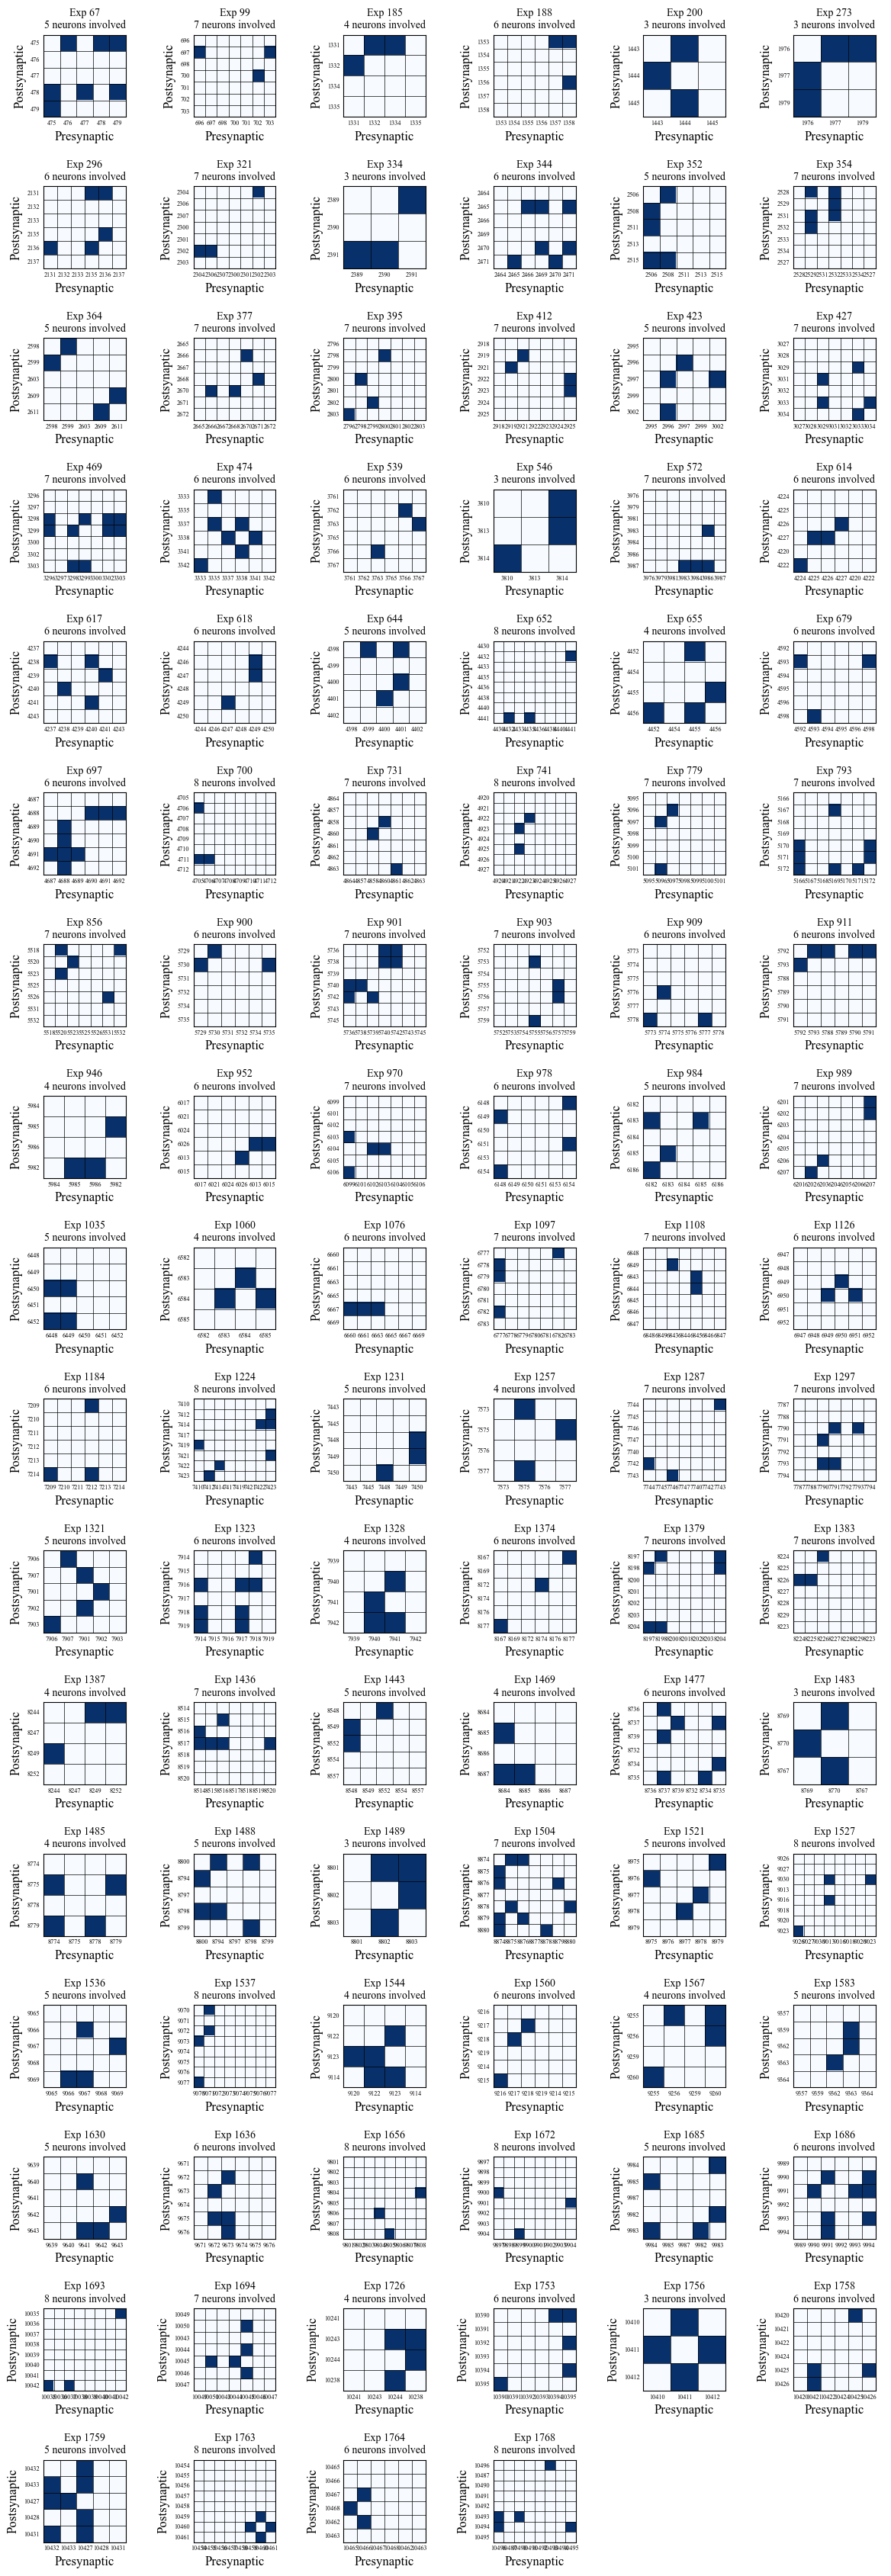

In [19]:
completed_experiments = []

# -------------------- Specific experiments --------------------
# Query for experiments satisfying a specific criteria, here above a certain number of synapses

query = """ 
            SELECT 
                p.experiment_id,
                COUNT(*) AS total_pairs,
                SUM(p.has_synapse) AS num_synapses,
                COUNT(*) - SUM(p.has_synapse) AS num_no_synapses


            FROM pair p

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id


            WHERE 
                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- No null values in synapse and cell classes
                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'
                
            GROUP BY p.experiment_id
            HAVING num_synapses > 1
            ;
        """

experiments = pd.read_sql_query(query, con)

# valid_experiments = df_num_synapses["experiment_id"].tolist()
# was_synapse = df_was_synapse["experiment_id"].unique().tolist()
experiment_ids = experiments["experiment_id"].unique().tolist()

# for exp in valid_experiments:  # uncomment if wall experiments
# for exp in was_synapse:  # only when there was a synapse
for exp in experiment_ids:
    df = df_valid_experiments[(df_valid_experiments["experiment_id"]==exp)]
    pres = df["pre_cell_id"].unique().tolist()
    posts = df["post_cell_id"].unique().tolist()
    total_neurons = list(set(pres) | set(posts))
    n = len(total_neurons)
    possible_synapses = n * (n - 1)

    df_distinct_cells = df[df["pre_cell_id"] != df["post_cell_id"]]  # distinct cells in pre and post
    unique_synapses = df_distinct_cells[['pre_cell_id', 'post_cell_id']].drop_duplicates()  # drop duplicates

    if len(unique_synapses == possible_synapses):
        completed_experiments.append((exp, df, total_neurons))


print(f"Total experiments: {len(completed_experiments)}")
# print(completed_experiments)

# Plot the first 100 valid experiments
n_max = min(100, len(completed_experiments))
n_cols = 6
n_rows = int(np.ceil(n_max / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2*n_rows))
axs = axs.flatten()

flag = 0

rows = []

# Make adjacency matrices
for i, (exp, df, total_neurons) in enumerate(completed_experiments[:n_max]):
    n = len(total_neurons)
    idx_map = {neuron: idx for idx, neuron in enumerate(total_neurons)}  # mapping neuron to index
    adj = np.zeros((n, n))

    synapses = []

    for _, row in df.iterrows():  # iterates through the dataframe
        flag += 1
        pre = row["pre_cell_id"]
        post = row['post_cell_id']
        i_pre = idx_map[pre]
        i_post = idx_map[post]
        # adj[i_pre, i_post] = 1 if row["has_synapse"] == 1 else 0 # ??????? other way around maybe
        adj[i_post, i_pre] = 1 if row["has_synapse"] == 1 else 0  # row is postsynaptic, column is presynaptic


    ax = axs[i]
    im = ax.imshow(adj, cmap="Blues", interpolation='none')

    # (n, n) matrix with cell centers at 0, 1, 2, ..., n-1, and cell borders at -0.5, 0.5, 1.5, ..., n-0.5
    # include minor and major ticks

    neurons = adj.shape[0]

    # Major ticks (centers)
    ax.set_xticks(np.arange(neurons))
    ax.set_yticks(np.arange(neurons))

    # Labels 0 to n-1
    labels = [neuron for neuron, _ in sorted(idx_map.items(), key=lambda x: x[1])]
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # Minor ticks (borders)
    ax.set_xticks(np.arange(-.5, neurons, 1), minor=True)
    ax.set_yticks(np.arange(-.5, neurons, 1), minor=True)

    # Draw grid using minor ticks
    ax.grid(which="minor", color='black', linestyle='-', linewidth=0.5)

    # Hide minor tick marks themselves
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(which="major", bottom=False, left=False)


    ax.set_title(f"Exp {exp}\n{n} neurons involved", fontsize=10)
    ax.set_xlabel("Presynaptic")
    ax.set_ylabel("Postsynaptic")

    ax.set_xlim(-0.5, (neurons - 0.5))
    ax.set_ylim((neurons - 0.5), -0.5) # flipped y axis?



# Hide extra axes
for j in range(i+1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

# PSP

I follow the previously used requirements.
* Cell pair
    * Belong to an experiment
    * Belong to a mouse slice
    * Experiment targets VisP
    * Both cells exist
    * Both cell classes are known
    * Presynaptic cell is not mixed
* PSP amplitude
    * Not Null


PSP: magnitude of voltage change in a postsynaptic neuron, indicating excitatory (EPSP) or inhibitory (IPSP) strength

In [57]:
query = """SELECT * FROM intrinsic"""
df = pd.read_sql_query(query, con)
df


,id,cell_id,rheobase,fi_slope,input_resistance,input_resistance_ss,sag,tau,sag_peak_t,sag_depol,...,chirp_peak_ratio,chirp_peak_impedance,chirp_sync_freq,chirp_inductive_phase,isi_adapt_ratio,upstroke_adapt_ratio,downstroke_adapt_ratio,width_adapt_ratio,threshold_v_adapt_ratio,meta
0,1,22320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null
1,2,22321,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null
2,3,22322,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null
3,4,22323,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null
4,5,9771,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17935,18159,24758,NaN,NaN,6.384582e+07,6.060694e+07,0.042229,NaN,0.900203,0.239550,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null
17936,18160,24761,NaN,NaN,2.476528e+07,2.894325e+07,0.045504,NaN,0.839213,0.432015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null
17937,18161,24762,NaN,NaN,8.121874e+07,8.092382e+07,0.059986,NaN,0.523748,0.644732,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null
17938,18571,24815,NaN,NaN,9.230012e+07,9.277698e+07,0.037984,0.006541,0.274203,0.589737,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null


## Query to get data including intrinsic

Text(0.5, 0, 'PSP Amplitude (mV)')

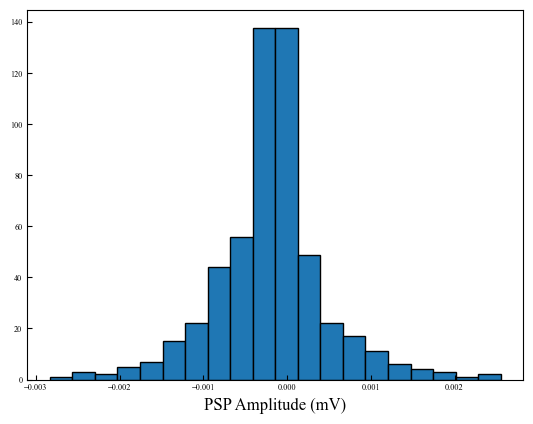

In [ ]:
## Histogram without requirements on number of datapoints
# Including "intrinsic" table in query

query = """ 
            SELECT 
                p.experiment_id,
                p.pre_cell_id, 
                p.post_cell_id, 
                p.has_synapse, 
                pre.cell_class AS pre_cell_class,
                post.cell_class AS post_cell_class,
                syn.psp_amplitude,
                i_pre.fi_slope AS pre_fi_slope,
                i_post.fi_slope AS post_fi_slope

            FROM pair p


            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id
            INNER JOIN synapse syn ON syn.pair_id = p.id


            WHERE 

                -- Brain specs 

                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- Null value filtering

                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL
                AND syn.psp_amplitude IS NOT NULL
                AND i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'
                
            ; 
        """

df = pd.read_sql_query(query, con)

plt.hist(df['psp_amplitude'], bins=20, edgecolor='k')
plt.xlabel('PSP Amplitude (mV)')

## N datapoints

In [21]:
# Including "intrinsic" table in query
# this includes PSP amplitude and fi slope pre and post, but only include those where we have over 10

query = """ 
            SELECT 
                p.experiment_id,
                p.pre_cell_id, 
                p.post_cell_id, 
                p.has_synapse, 
                pre.cell_class AS pre_cell_class,
                post.cell_class AS post_cell_class,
                syn.psp_amplitude,
                e.target_region,
                i_pre.fi_slope AS pre_fi_slope,
                i_post.fi_slope AS post_fi_slope

            FROM pair p


            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id
            INNER JOIN synapse syn ON syn.pair_id = p.id


            WHERE 

                -- Brain specs 

                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- Null value filtering

                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL
                AND syn.psp_amplitude IS NOT NULL
                AND i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'
                
            GROUP BY p.experiment_id HAVING COUNT(*) > 6
            ; 
        """

df_experiments_n_datapoints = pd.read_sql_query(query, con)

df_experiments_n_datapoints


,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,psp_amplitude,target_region,pre_fi_slope,post_fi_slope
0,2342,13652,13653,1,ex,in,0.000061,VisP,1.782213e-13,5.815596e-14
1,2920,16649,16650,1,in,in,-0.000340,VisP,3.543789e-13,1.037506e-14
2,3172,18059,18060,1,in,in,-0.000227,VisP,2.234083e-13,8.527234e-13
3,3228,18379,18381,1,ex,in,0.000105,VisP,8.793053e-14,1.637869e-13
4,3262,18564,18566,1,ex,in,0.000876,VisP,2.178256e-13,3.912468e-13


In [ ]:
#### Get counts of data points per experiment
# Data points in this case are synapses, so if there is 17 data points, it means 17 synapses


query = """ 
            SELECT 
                p.experiment_id,
                COUNT(DISTINCT p.id) AS num_data_points

            FROM pair p


            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id
            INNER JOIN synapse syn ON syn.pair_id = p.id


            WHERE 
                -- Brain specs 

                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- Null value filtering

                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL
                AND syn.psp_amplitude IS NOT NULL
                AND i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'
                
            GROUP BY p.experiment_id
            ORDER BY num_data_points DESC LIMIT 10
            ; 
        """

df_experiments_num_datapoints = pd.read_sql_query(query, con)

df_experiments_num_datapoints


,experiment_id,num_data_points
0,3172,17
1,3228,9
2,2342,7
3,2920,7
4,3262,7
5,793,6
6,1787,6
7,2771,6
8,2903,6
9,3171,6


In [26]:
query = """ 
            SELECT 
                p.experiment_id,
                p.id AS pair_id,
                p.pre_cell_id, 
                p.post_cell_id, 
                syn.psp_amplitude,
                i_pre.fi_slope AS fi_slope_pre,
                i_post.fi_slope AS fi_slope_post
                


            FROM pair p

            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN synapse syn ON syn.pair_id = p.id
            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
                ; 
        """

df = pd.read_sql_query(query, con)

df


,experiment_id,pair_id,pre_cell_id,post_cell_id,psp_amplitude,fi_slope_pre,fi_slope_post
0,2799,88744,15996,15994,NaN,1.345974e-13,NaN
1,4603,119060,23282,23284,0.000014,NaN,NaN
2,715,30118,4778,4777,0.000953,NaN,NaN
3,4878,121773,24176,24179,NaN,2.058123e-12,7.423880e-13
4,1655,56173,9799,9797,NaN,8.190477e-13,-9.047620e-14
...,...,...,...,...,...,...,...
3275,2538,81802,14656,14660,0.000031,NaN,NaN
3276,2538,81804,14656,14662,NaN,NaN,NaN
3277,2538,81806,14657,14656,0.000271,NaN,NaN
3278,2538,81816,14658,14660,0.001185,NaN,NaN


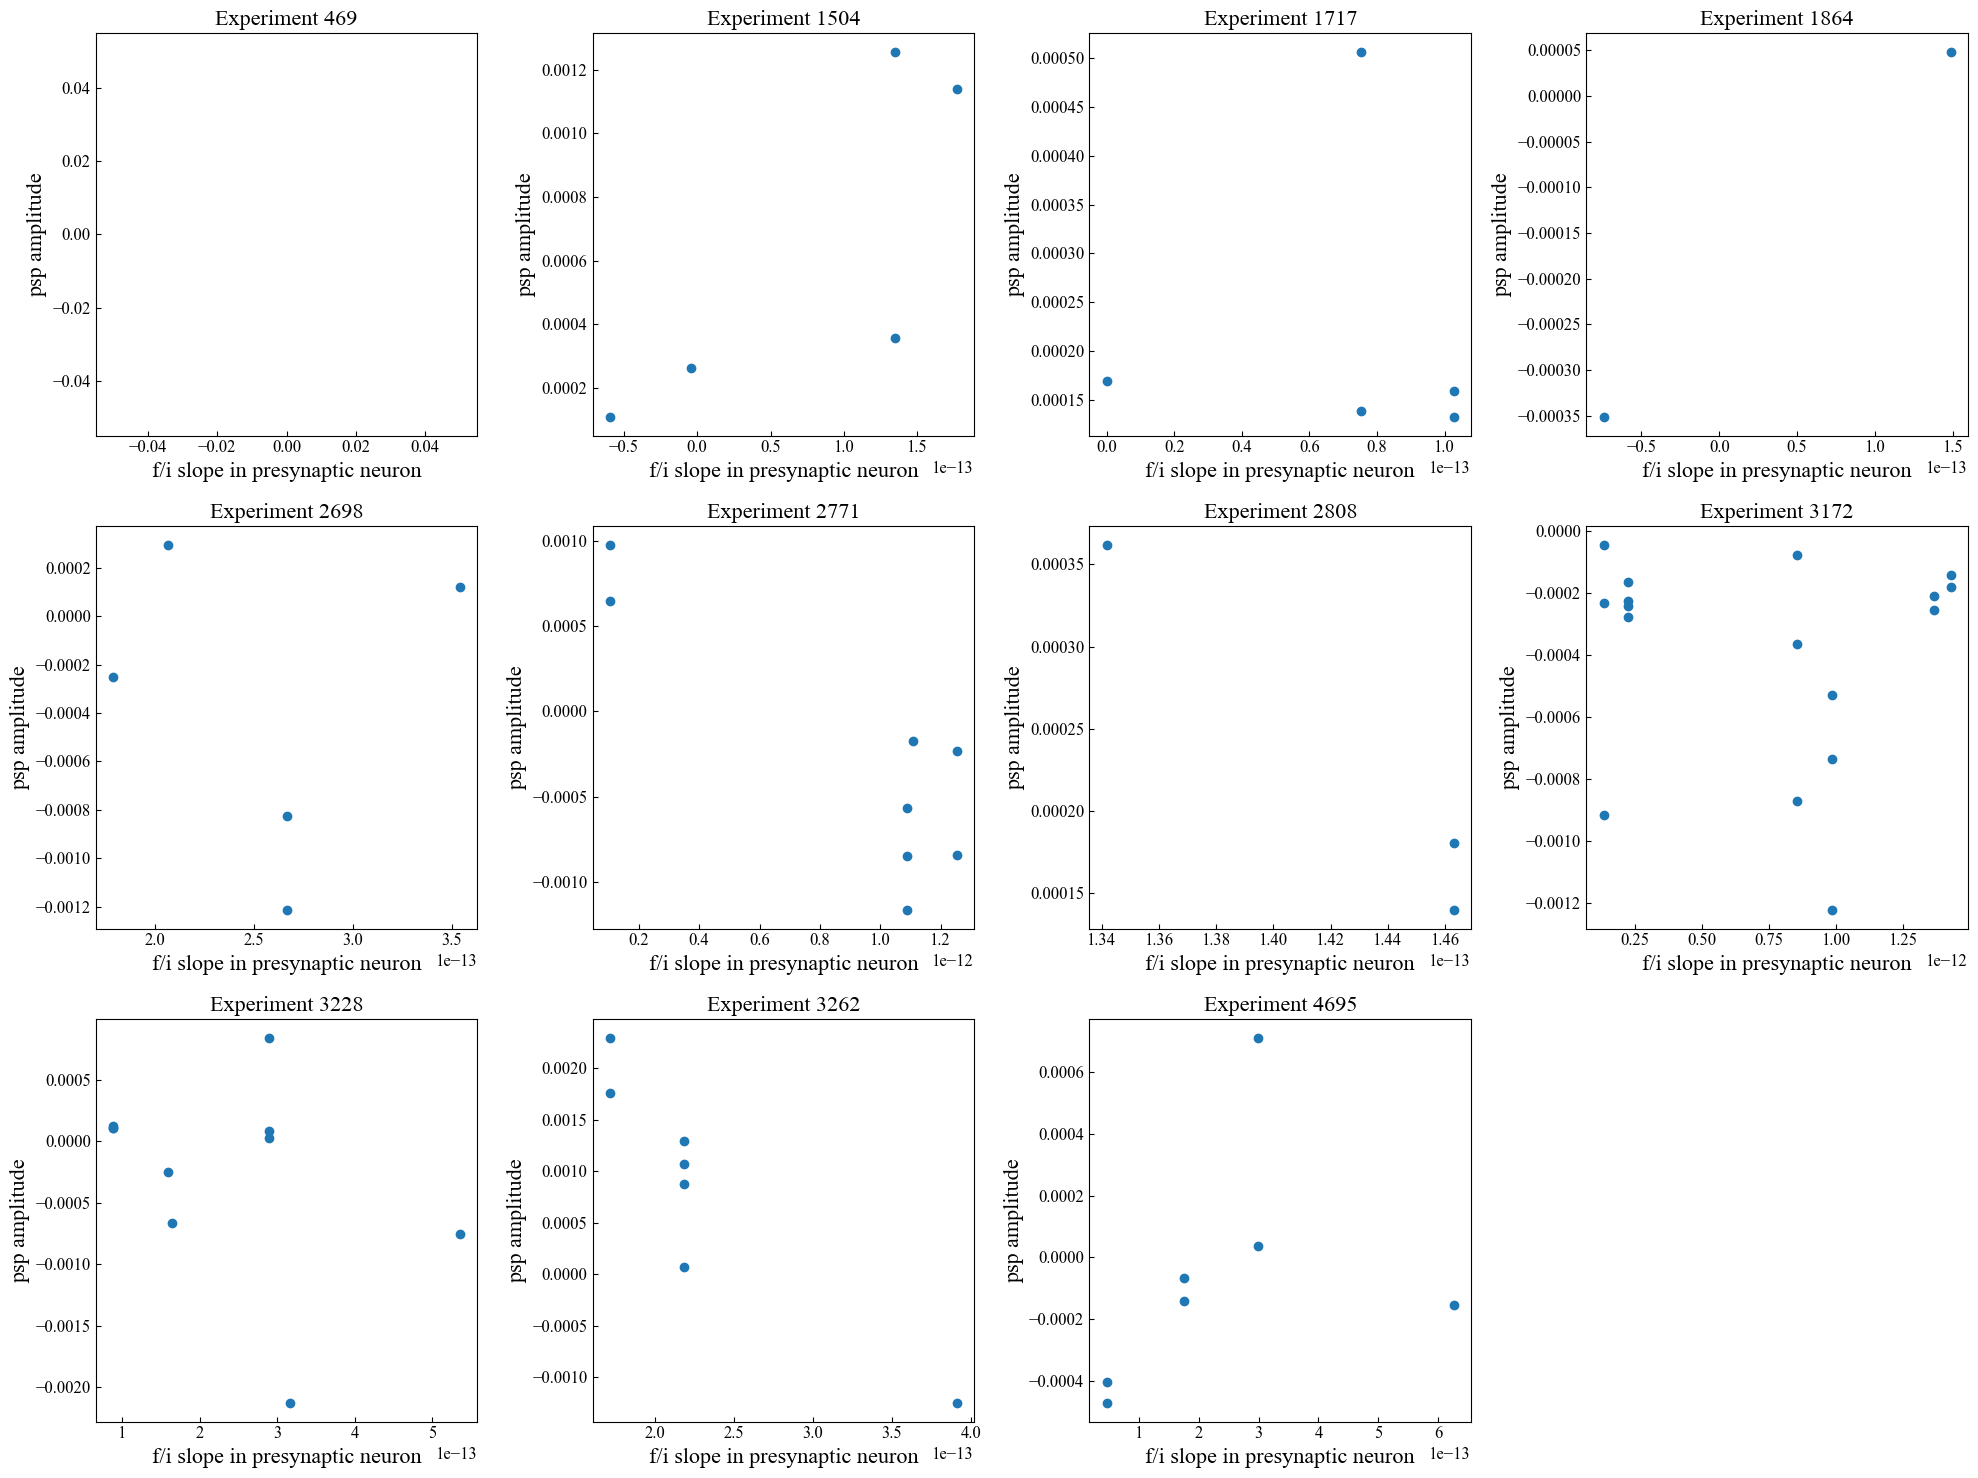

In [40]:
#### Query to get which experiment had more than a certain nnumber of datapoints

query = """ 
            SELECT 
                p.experiment_id,
                e.target_region,
                COUNT(DISTINCT p.id) AS num_data_points

            FROM pair p


            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id
            INNER JOIN synapse syn ON syn.pair_id = p.id

                
            GROUP BY p.experiment_id
            HAVING num_data_points > 10
            ; 
        """

df = pd.read_sql_query(query, con)
experiments_ten_datapoints = df["experiment_id"]  # already unique, gives a series with experiment ids
# valid_experiments = [experiment_id for experiment_id in experiments_ten_datapoints if experiment_id not in excluded_experiments]
valid_experiments = [experiment_id for experiment_id in experiments_ten_datapoints]

# Number of subplots
n_experiments = len(valid_experiments)  # Should only include those with more than 10 data points


########## Access info for these experiments (no filters)
# One point in the plot is a synapse
query = """ 
            SELECT 
                p.experiment_id,
                p.id AS pair_id,
                p.pre_cell_id, 
                p.post_cell_id, 
                syn.psp_amplitude,
                i_pre.fi_slope AS fi_slope_pre,
                i_post.fi_slope AS fi_slope_post
                


            FROM pair p

            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN synapse syn ON syn.pair_id = p.id
            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
                ; 
        """

df_experiments = pd.read_sql_query(query, con)

df_experiments


# If there are no experiments, do nothing
if n_experiments == 0:
    print("No experiments with sufficient data were found.")
else:
    # Calculate rows and columns for subplots
    n_cols = int(np.ceil(np.sqrt(n_experiments)))  # Number of columns
    n_rows = int(np.ceil(n_experiments / n_cols))  # Number of rows
    
    # Determine figure size based on number of subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))

    # Flatten the axes array for easier access
    axes = axes.flatten()

    # Loop through each considered experiment
    for i, experiment_id in enumerate(valid_experiments):
        df_exp = df_experiments[df_experiments['experiment_id'] == experiment_id]
        # possibly also:
        # df_exp_clean = df_exp[['pre_fi_slope','psp_amplitude']].dropna()
        x = df_exp['fi_slope_pre'].values
        y = df_exp['psp_amplitude'].values


        axes[i].scatter(x, y)
        axes[i].set_title(f'Experiment {experiment_id}')
        # plt.colorbar(im, ax=axes[i], label='PSP Amplitude')

        axes[i].set_xlabel(f"f/i slope in presynaptic neuron")
        axes[i].set_ylabel(f"psp amplitude")



    # Remove empty axes if there are fewer experiments than subplots
    for j in range(n_experiments, len(axes)):
        axes[j].axis('off')
        axes[j].set_xticks([])
        axes[j].set_yticks([])

    # Adjust subplots
    plt.tight_layout()
    plt.show()


# PSP Matrix without the constraints

In [7]:
plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 14,                  # Base size 8-12 pt
    # Axes
    "axes.titlesize": 16,             # Axis title size
    "axes.labelsize": 16,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles
    # Ticks
    "xtick.labelsize": 12,             # X tick label size (8-12)
    "ytick.labelsize": 12,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction
    # Legends
    "legend.fontsize": 12,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location
    # Resolution
    # "figure.dpi": 500,                # Display DPI  UNCOMMENT LATER. I commented it out now while I work on it, because Jupyter displayed pixel size = figsize * figure.dpi, causing huge images now in the notebook
    "figure.dpi": 100,
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace
    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif
    # Make text editable in Inkscape
    "svg.fonttype": 'none',
})

In [11]:
#### Get counts of data points per experiment, no filtering
# Changed to counting pairs


query = """ 
            SELECT 
                p.experiment_id,
                e.target_region,
                COUNT(DISTINCT p.id) AS num_data_points

            FROM pair p


            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id
            INNER JOIN synapse syn ON syn.pair_id = p.id

                
            GROUP BY p.experiment_id
            HAVING COUNT(DISTINCT p.id) > 10
            ORDER BY num_data_points DESC
            ; 
        """

df_experiments_num_datapoints = pd.read_sql_query(query, con)
experiments_ten_datapoints = df_experiments_num_datapoints["experiment_id"]  # already unique
# df_experiments_num_datapoints

# print(experiments_ten_datapoints)
print(len(experiments_ten_datapoints))
df_experiments_num_datapoints

11


,experiment_id,target_region,num_data_points
0,3172,VisP,19
1,2698,TCx,13
2,2771,VisP,13
3,3228,VisP,13
4,469,VisP,12
5,2808,VisP,12
6,1504,VisP,11
7,1717,TCx,11
8,1864,VisP,11
9,3262,VisP,11


In [12]:
#### Get counts of data points per experiment with filters


query = """ 
            SELECT 
                p.experiment_id,
                COUNT(DISTINCT p.id) AS num_data_points

            FROM pair p


            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id
            INNER JOIN synapse syn ON syn.pair_id = p.id


            WHERE 
                -- Brain specs 

                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- Null value filtering

                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL
                AND syn.psp_amplitude IS NOT NULL
                AND i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'
                
            GROUP BY p.experiment_id
            --ORDER BY num_data_points DESC LIMIT 10
            HAVING COUNT(DISTINCT p.id) > 10
            ; 
        """

df_experiments_num_datapoints = pd.read_sql_query(query, con)

df_experiments_num_datapoints


,experiment_id,num_data_points
0,3172,17


In [13]:

query = """ 
            SELECT 
                p.experiment_id,
                p.id AS pair_id,
                p.pre_cell_id, 
                p.post_cell_id, 
                syn.psp_amplitude,
                i_pre.fi_slope AS fi_slope_pre,
                i_post.fi_slope AS fi_slope_post
                


            FROM pair p

            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN synapse syn ON syn.pair_id = p.id
            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id


            WHERE

                syn.psp_amplitude IS NOT NULL
                AND i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL
                AND i_pre.fi_slope > 0
                AND i_post.fi_slope > 0
                AND p.has_synapse IS NOT NULL
                ; 
        """

df_experiments = pd.read_sql_query(query, con)

df_experiments


,experiment_id,pair_id,pre_cell_id,post_cell_id,psp_amplitude,fi_slope_pre,fi_slope_post
0,3271,102624,18608,18612,0.004912,5.952383e-15,2.881222e-13
1,3270,102619,18606,18607,0.000393,2.085229e-13,9.777069e-14
2,3274,102709,18625,18622,-0.000900,4.019802e-13,1.151387e-13
3,3502,108220,19758,19760,0.000111,2.379171e-13,7.093534e-14
4,3274,102675,18622,18625,0.000104,1.151387e-13,4.019802e-13
...,...,...,...,...,...,...,...
731,2326,76208,13574,13575,0.000145,5.792521e-13,1.807065e-13
732,2793,88588,15964,15961,-0.000026,1.914810e-13,3.033021e-13
733,5105,123616,24778,24781,-0.000198,8.018796e-13,9.525691e-14
734,5117,123712,24813,24814,0.000379,7.079645e-14,7.336674e-13


In [14]:
# Define experiments to exclude
# excluded_experiments = {469, 1504, 1864, 2218, 2808, 2913}  # why
excluded_experiments = {}

# Filter valid experiments (without excluded ones)
# valid_experiments = [experiment_id for experiment_id in valid_experiment_ids if experiment_id not in excluded_experiments]
valid_experiments = [experiment_id for experiment_id in experiments_ten_datapoints if experiment_id not in excluded_experiments]

# Number of subplots
n_experiments = len(valid_experiments)
print(n_experiments)

11


In [51]:
pd.read_sql_query("SELECT * FROM slice WHERE species != 'mouse';", con)

,id,ext_id,acq_timestamp,species,date_of_birth,age,sex,weight,genotype,orientation,surface,hemisphere,quality,slice_time,slice_conditions,lims_specimen_name,storage_path,meta
0,92,1485896831.732,1.485897e+09,human,None,12410,F,None,None,variable,None,None,NaN,2017-01-31 13:00:00.000000,{},H16.06.013.11.11,1485896796.778/slice_000,null
1,185,1488322902.983,1.488323e+09,human,None,13870,M,None,None,variable,None,None,3.0,None,{},H17.06.005.12.09,1488322897.472/slice_000,null
2,186,1488325065.608,1.488325e+09,human,None,13870,M,None,None,variable,None,None,NaN,2017-02-28 10:45:00.000000,{},H17.06.005.12.04,1488324593.035/slice_000,null
3,196,1488402743.242,1.488403e+09,human,None,12775,M,None,None,variable,None,None,NaN,2017-02-28 16:42:00.000000,{},H17.06.006.11.14,1488402582.997/slice_000,null
4,420,1494359060.651,1.494359e+09,human,None,21900,M,None,None,variable,None,None,NaN,2017-05-09 10:17:00.000000,{},H17.03.005.11.05.01,1494358954.069/slice_000,null
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,3046,1582702617.619,1.582703e+09,human,None,21535,M,None,None,variable,None,None,NaN,None,{},H20.06.351.11.12.01,1582682343.918/slice_001,null
334,3061,1579903688.177,1.579904e+09,human,None,10220,M,None,rAAV-3xhI56i(core)-minBglobin-SYFP2-WPRE3-BGHpA,variable,None,None,3.0,None,{},H20.03.302.11.55.01,1579903595.677/slice_000,null
335,3089,1579641595.466,1.579642e+09,human,None,21170,M,None,rAAV-Dlx2.0-SYFP2,variable,None,None,2.0,None,{},H20.26.401.11.54.01,1579641593.822/slice_000,null
336,3989,1624648811.536,1.624649e+09,human,None,18615,F,None,None,variable,None,None,2.0,2021-06-24 19:35:00.000000,{},H21.06.353.11.05.01,1624622815.782/slice_000,null


In [15]:
folder = f"data_analysis/saved_data"

# PSP matrix with record of FI slope for cells

In [118]:
df = main_df.copy()

df

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,pre_fi_category,post_fi_category,psp_amplitude,synapse_id,pre_mu,pre_sigma,post_mu,post_sigma
0,600,4133,4138,0,in,in,8.230065e-13,1.105000e-12,medium,high,NaN,NaN,4.054656e-13,6.913182e-13,4.054656e-13,6.913182e-13
1,600,4133,4140,0,in,ex,8.230065e-13,1.131452e-13,medium,medium,NaN,NaN,4.054656e-13,6.913182e-13,4.054656e-13,6.913182e-13
2,600,4133,4142,0,in,in,8.230065e-13,8.820777e-13,medium,medium,NaN,NaN,4.054656e-13,6.913182e-13,4.054656e-13,6.913182e-13
3,600,4138,4133,0,in,in,1.105000e-12,8.230065e-13,high,medium,NaN,NaN,4.054656e-13,6.913182e-13,4.054656e-13,6.913182e-13
4,600,4138,4140,1,in,ex,1.105000e-12,1.131452e-13,high,medium,-0.000204,1895.0,4.054656e-13,6.913182e-13,4.054656e-13,6.913182e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7686,5108,24790,24791,1,ex,in,6.639170e-14,4.244768e-13,medium,medium,NaN,3384.0,4.054656e-13,6.913182e-13,4.054656e-13,6.913182e-13
7687,5108,24791,24790,1,in,ex,4.244768e-13,6.639170e-14,medium,medium,-0.000314,3391.0,4.054656e-13,6.913182e-13,4.054656e-13,6.913182e-13
7688,5110,24799,24798,0,in,mixed,5.590663e-13,3.932555e-13,medium,medium,NaN,NaN,4.054656e-13,6.913182e-13,4.054656e-13,6.913182e-13
7689,5117,24813,24814,1,ex,in,7.079645e-14,7.336674e-13,medium,medium,0.000379,3374.0,4.054656e-13,6.913182e-13,4.054656e-13,6.913182e-13


In [131]:
# Convert the dataframe to a numpy array

def motifs(w,N):
   '''
   Takes the psp matrix, and how many neurons, and perform motif calculations
   
   '''
   w=w-np.mean(w)
   ww=np.matmul(w,w)
   wtw=np.matmul(w.T,w)
   wwt=np.matmul(w,w.T)
   sigma2=np.trace(wwt)/N
   tau_rec=np.trace(ww)
   tau_rec/=sigma2*N
   tau_div=np.sum(wwt)-np.trace(wwt)
   tau_div/=sigma2*N*(N-1)
   tau_con=np.sum(wtw)-np.trace(wtw)
   tau_con/=sigma2*N*(N-1)
   tau_chn=2*(np.sum(ww)-np.trace(ww))
   tau_chn/=sigma2*N*(N-1)
   return tau_rec,tau_div,tau_con,tau_chn

   


query = """
            SELECT
                p.experiment_id,
                p.id AS pair_id,
                p.pre_cell_id,
                p.post_cell_id,
                syn.psp_amplitude,
                i_pre.fi_slope AS fi_slope_pre,
                i_post.fi_slope AS fi_slope_post

            FROM pair p

            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN synapse syn ON syn.pair_id = p.id
            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
            INNER JOIN slice s ON e.slice_id = s.id

            WHERE p.experiment_id IN (

                SELECT
                    p2.experiment_id

                FROM pair p2

                INNER JOIN cell pre2 ON p2.pre_cell_id = pre2.id
                INNER JOIN cell post2 ON p2.post_cell_id = post2.id
                INNER JOIN intrinsic i_pre2 ON p2.pre_cell_id = i_pre2.cell_id
                INNER JOIN intrinsic i_post2 ON p2.post_cell_id = i_post2.cell_id
                INNER JOIN experiment e2 ON e2.id = p2.experiment_id
                INNER JOIN slice s2 ON e2.slice_id = s2.id
                INNER JOIN synapse syn2 ON syn2.pair_id = p2.id

                GROUP BY p2.experiment_id
                HAVING COUNT(DISTINCT p2.id) > 6
            )

            AND s.species = 'mouse' 
            AND e.target_region = 'VisP' 

            -- No null values in synapse and cell classes
            AND p.has_synapse IS NOT NULL
            AND pre.cell_class IS NOT NULL
            AND post.cell_class IS NOT NULL

            AND i_pre.fi_slope IS NOT NULL
            AND i_post.fi_slope IS NOT NULL

            AND syn.psp_amplitude IS NOT NULL

            -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
            AND pre.cell_class != 'mixed'
            ;
        """

# df_experiments = pd.read_sql_query(query, con)

df_temp = main_df.copy()
df_experiments = df_temp.dropna(subset=['psp_amplitude'])

# Get experiment IDs
valid_experiments = df_experiments["experiment_id"].unique()
n_experiments = len(valid_experiments) 

k = 15
k_experiments = valid_experiments[:k]

print(n_experiments)

exp_gains = {}
exp_motifs = {}

# If there are no experiments, do nothing
if n_experiments == 0:
    print("No experiments with sufficient data were found.")
else:
    # Calculate rows and columns for subplots
    n_cols = int(np.ceil(np.sqrt(n_experiments)))  # Number of columns
    n_rows = int(np.ceil(n_experiments / n_cols))  # Number of rows
    
    # Determine figure size based on number of subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))

    # Flatten the axes array for easier access
    axes = axes.flatten()

    # Loop through each considered experiment
    for i, experiment_id in enumerate(valid_experiments):
    # for i, experiment_id in enumerate(k_experiments):
        df_exp = df_experiments[df_experiments['experiment_id'] == experiment_id]
        pres_fi = []
        posts_fi = []

        # Generate PSP matrix for the experiment
        all_cells = np.sort(pd.unique(df_exp[['pre_cell_id', 'post_cell_id']].values.ravel()))
        df_psp_matrix = pd.DataFrame(np.nan, index=all_cells, columns=all_cells)

        for _, row in df_exp.iterrows():
            pre_cell = row['pre_cell_id']
            post_cell = row['post_cell_id']
            psp_value = row['psp_amplitude']
            # df_psp_matrix.loc[pre_cell, post_cell] = psp_value
            df_psp_matrix.loc[post_cell, pre_cell] = psp_value  # changed to postsynaptic in row, presynaptic in column

            # temp_exp_id = row['experiment_id']
            pre_cell_fi = row['fi_slope_pre']
            post_cell_fi = row['fi_slope_post']
            pres_fi.append(pre_cell_fi)
            posts_fi.append(post_cell_fi)

        exp_gains[experiment_id] = [pres_fi, posts_fi]
            

        df_psp_matrix.to_csv(f'saved_data/{experiment_id}_PSP_matrix.csv')

        psp_matrix_numpy = df_psp_matrix.values

        
        masked_psp_matrix = np.ma.masked_invalid(psp_matrix_numpy)  # Masked array that suppress all NaN values


        # Plot the PSP matrix in the corresponding subplot
        if not np.isfinite(masked_psp_matrix).any():
        # all entries are NaN (or +/-inf); skip this iteration
            continue

        
        # TODO motif here

        # df_psp_matrix.fillna(0, inplace=True)
        # psp_matrix_numpy = df_psp_matrix.values
        # # Modify the output print to get values as simple floats
        # motif_result = motifs(psp_matrix_numpy, len(all_cells))
        # exp_motifs[experiment_id] = motif_result
        
        abs_max = np.nanmax(np.abs(psp_matrix_numpy))  # Ignore NaN when calculating maximum
        im = axes[i].imshow(masked_psp_matrix, cmap='viridis', interpolation='none', vmin=-abs_max, vmax=abs_max)
        axes[i].set_title(f'Experiment {experiment_id}')
        plt.colorbar(im, ax=axes[i], label='PSP Amplitude')

        axes[i].set_xlabel(f"Presynaptic")
        axes[i].set_ylabel(f"Postsynaptic")



    # Remove empty axes if there are fewer experiments than subplots
    for j in range(n_experiments, len(axes)):
        axes[j].axis('off')
        axes[j].set_xticks([])
        axes[j].set_yticks([])

    # Adjust subplots
    plt.tight_layout()
    plt.show()

print(exp_gains)

# for motifs in exp_motifs.values():
#     print(f"tau_rec: {motifs[0].item():.5f}, tau_div: {motifs[1].item():.5f}, tau_con: {motifs[2].item():.5f}, tau_chn: {motifs[3].item():.5f}")


281


{np.int64(600): [[1.1049999290466287e-12, 1.1314518997244929e-13], [1.1314518997244929e-13, 8.230065275570381e-13]], np.int64(610): [[-1.9230708285885797e-15], [7.692308149393981e-14]], np.int64(614): [[6.599999435424805e-13], [1.9999999999999996e-13]], np.int64(699): [[1.1587301587301576e-13], [-1.2698412698412693e-14]], np.int64(700): [[1.4625000000000003e-12], [5.062499930755573e-13]], np.int64(727): [[9.277238769948711e-15, 9.328571575304895e-15], [6.240000309448211e-14, 4.347428548316169e-13]], np.int64(729): [[8.388078039309849e-14], [-6.942505546770364e-15]], np.int64(731): [[-8.975609755734429e-14], [9.062499891607814e-13]], np.int64(772): [[1.281853281853279e-13], [-2.1930501930501896e-13]], np.int64(779): [[1.2499999205271414e-14], [-3.999998735700493e-14]], np.int64(793): [[1.3142856574026038e-13, 1.3142856574026038e-13, 6.499999459584584e-13, 4.4571424359172593e-13, -1.3559321157208228e-14, -1.3559321157208228e-14], [2.428571353315485e-13, 4.4571424359172593e-13, -1.3559321

In [ ]:
# FI slopes for the cells involved

for fi in exp_gains.values():
    print(f"Pre: {fi[0]}\nPost: {fi[1]}")

Pre: [np.float64(6.599999435424805e-13)]
Post: [np.float64(1.9999999999999996e-13)]
Pre: [np.float64(1.3142856574026038e-13), np.float64(1.3142856574026038e-13), np.float64(6.499999459584584e-13), np.float64(4.4571424359172593e-13), np.float64(-1.3559321157208228e-14), np.float64(-1.3559321157208228e-14)]
Post: [np.float64(2.428571353315485e-13), np.float64(4.4571424359172593e-13), np.float64(-1.3559321157208228e-14), np.float64(-1.3559321157208228e-14), np.float64(2.428571353315485e-13), np.float64(4.4571424359172593e-13)]
Pre: [np.float64(6.177606177606178e-14), np.float64(1.0656370656370646e-13), np.float64(8.8030888030888e-14), np.float64(2.7027015881093677e-14)]
Post: [np.float64(-8.648648648648622e-14), np.float64(-8.648648648648622e-14), np.float64(2.7027015881093677e-14), np.float64(1.0656370656370646e-13)]
Pre: [np.float64(2.0000000000000028e-13), np.float64(9.749998111724867e-13)]
Post: [np.float64(9.749998111724867e-13), np.float64(2.0000000000000028e-13)]
Pre: [np.float64(-

feks om hvorvidt det er fi_slope low-medium-high bestemmer disse matrisenes egenskaper?

In [39]:
experiments = [3172]

slopes = exp_gains[3172]

print(slopes[0])
print(max(slopes[0]))
print(min(slopes[0]))
print(slopes[1])
print(max(slopes[1]))
print(min(slopes[1]))

[np.float64(2.2340829607704675e-13), np.float64(2.2340829607704675e-13), np.float64(2.2340829607704675e-13), np.float64(2.2340829607704675e-13), np.float64(8.52723368437428e-13), np.float64(8.52723368437428e-13), np.float64(8.52723368437428e-13), np.float64(1.4265919200175117e-12), np.float64(1.4265919200175117e-12), np.float64(9.843537414965981e-13), np.float64(9.843537414965981e-13), np.float64(9.843537414965981e-13), np.float64(1.3413542131830134e-13), np.float64(1.3413542131830134e-13), np.float64(1.3413542131830134e-13), np.float64(1.3654089997998784e-12), np.float64(1.3654089997998784e-12)]
1.4265919200175117e-12
1.3413542131830134e-13
[np.float64(8.52723368437428e-13), np.float64(1.4265919200175117e-12), np.float64(9.843537414965981e-13), np.float64(1.3654089997998784e-12), np.float64(2.2340829607704675e-13), np.float64(1.4265919200175117e-12), np.float64(1.3654089997998784e-12), np.float64(8.52723368437428e-13), np.float64(1.3654089997998784e-12), np.float64(8.52723368437428e-1

In [47]:
slope_vals = cur.execute("""SELECT MAX(fi_slope), MIN(fi_slope), AVG(fi_slope) FROM intrinsic""").fetchall()

max, min, avg = slope_vals[0]

print(max)
print(min)
print(avg)

x_axis = [min, avg, max]

print(x_axis)

3.8943561546762944e-11
-3.20000305176071e-11
3.5902876328371054e-13
[-3.20000305176071e-11, 3.5902876328371054e-13, 3.8943561546762944e-11]


28


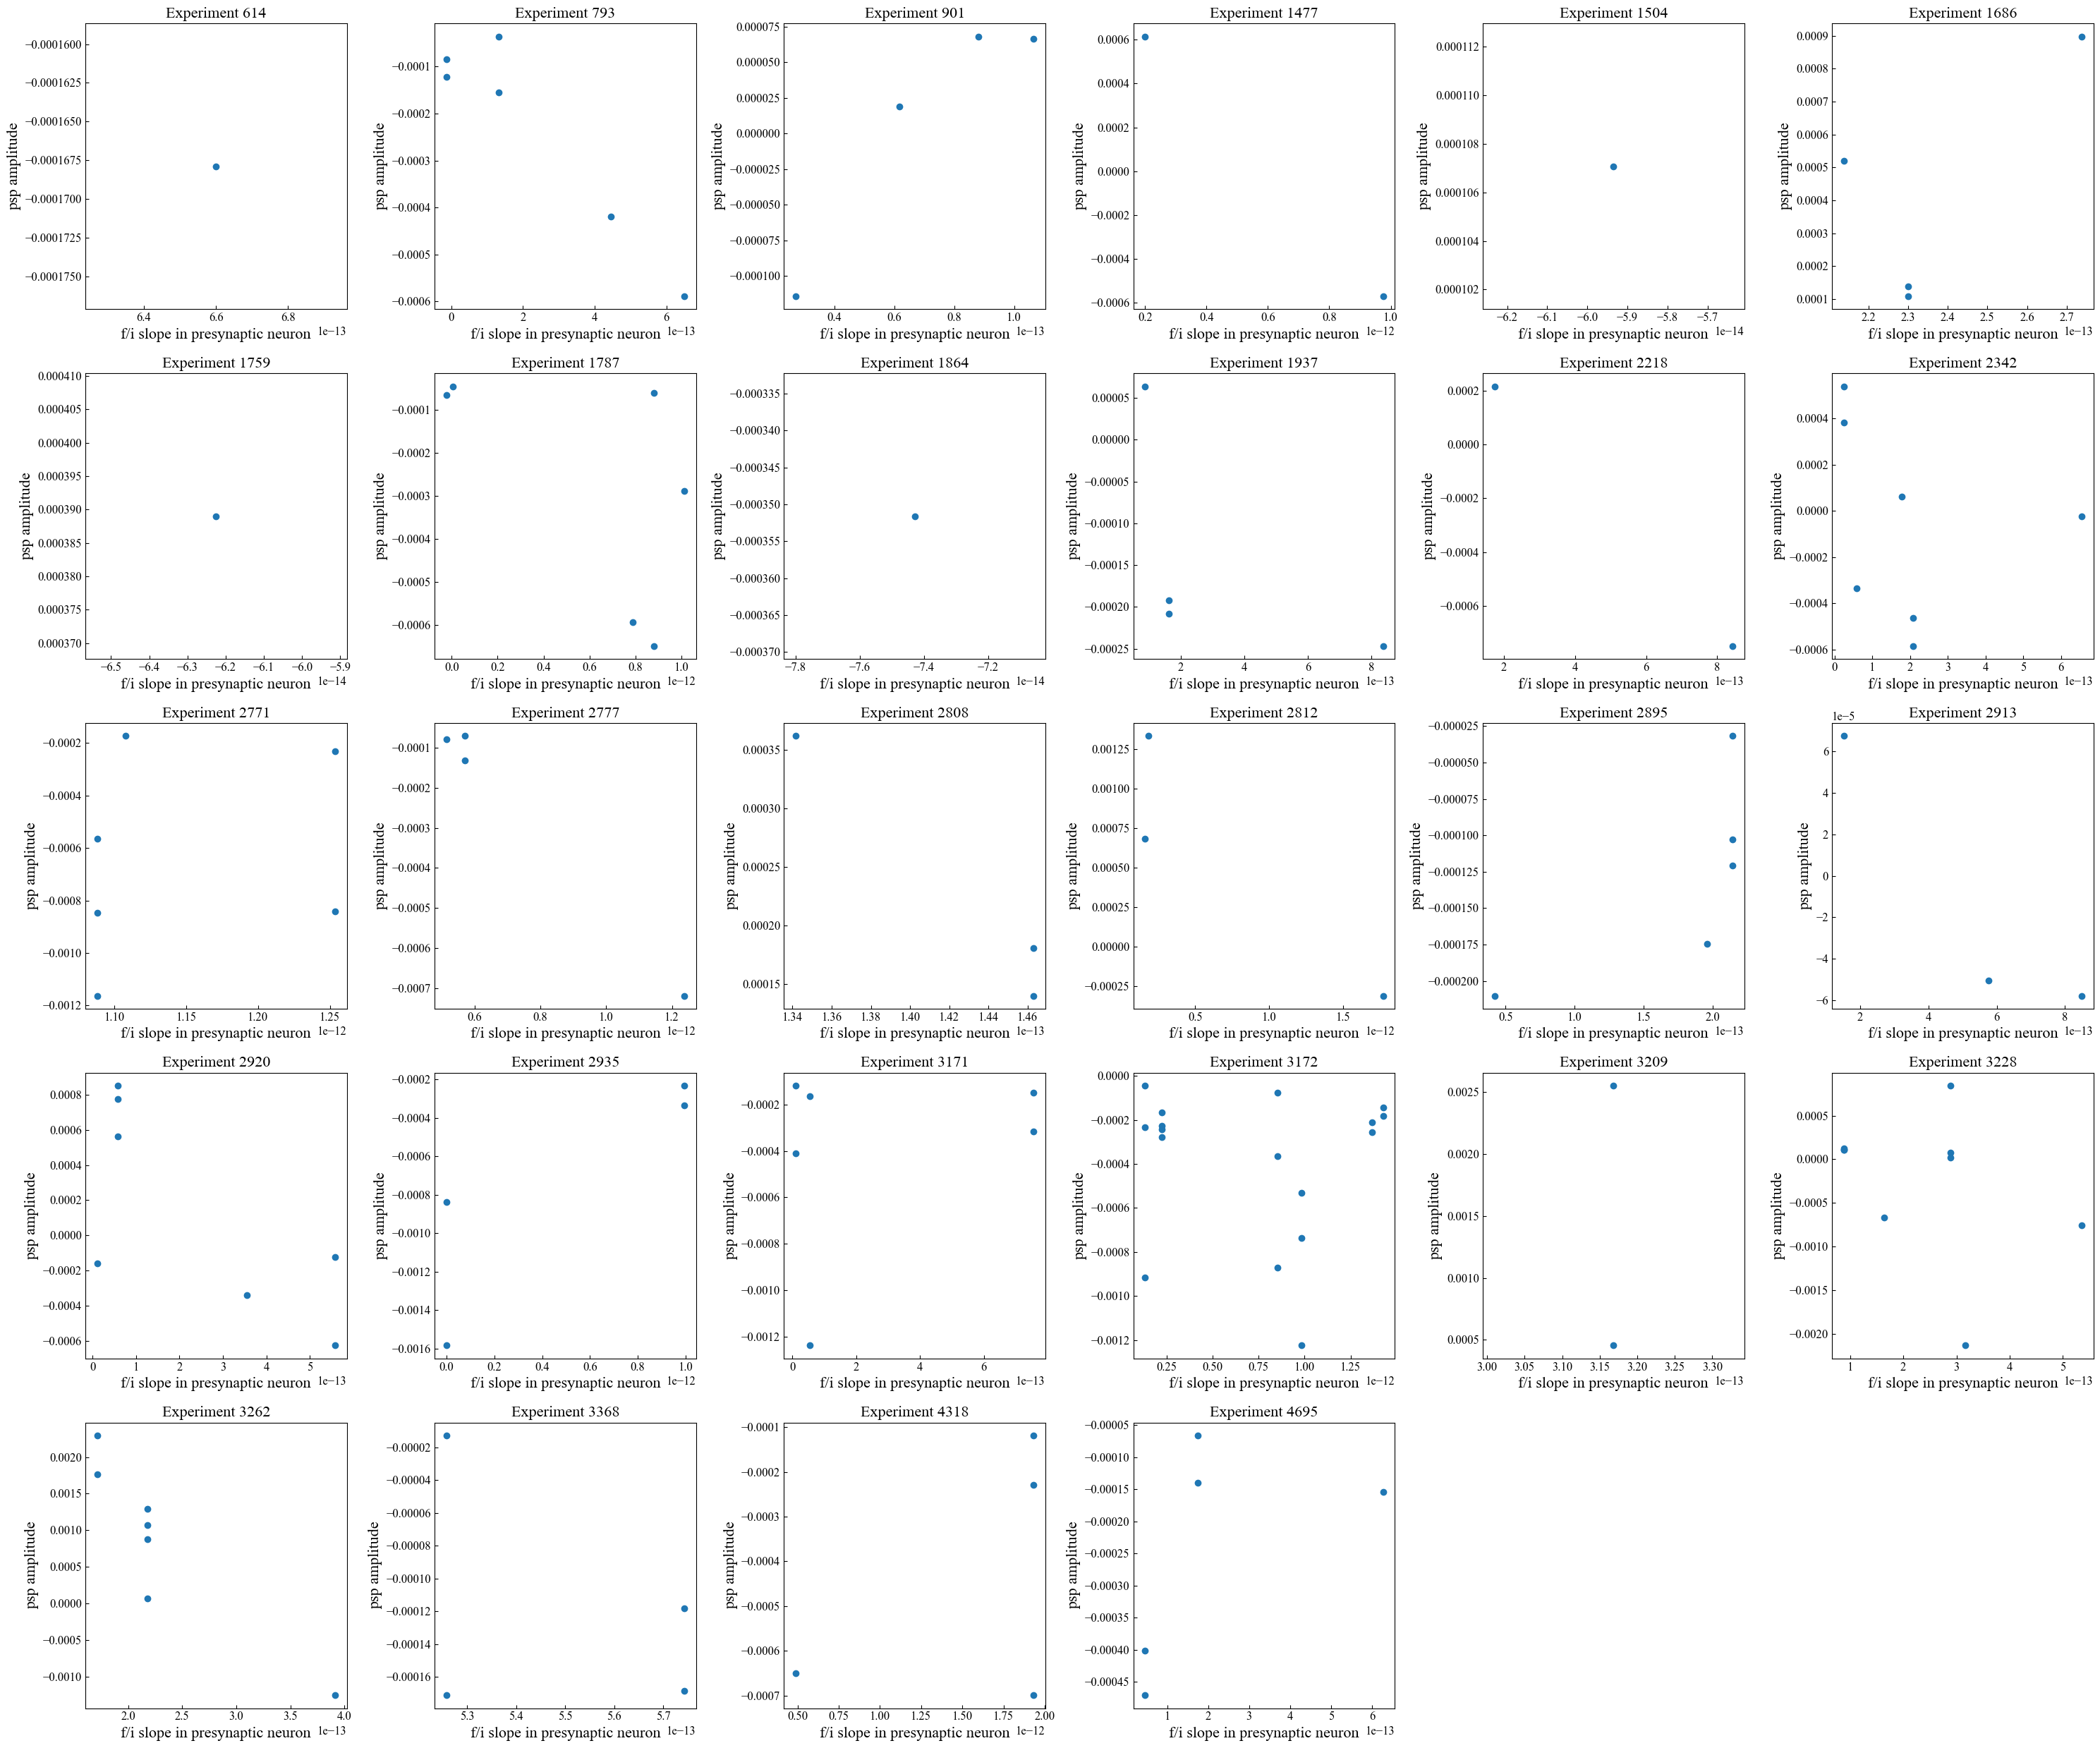

In [53]:
#### Query to get the experiments we are interested in

query = """
            SELECT
                p.experiment_id,
                p.id AS pair_id,
                p.pre_cell_id,
                p.post_cell_id,
                syn.psp_amplitude,
                i_pre.fi_slope AS fi_slope_pre,
                i_post.fi_slope AS fi_slope_post

            FROM pair p

            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN synapse syn ON syn.pair_id = p.id
            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
            INNER JOIN slice s ON e.slice_id = s.id

            WHERE p.experiment_id IN (

                SELECT
                    p2.experiment_id

                FROM pair p2

                INNER JOIN cell pre2 ON p2.pre_cell_id = pre2.id
                INNER JOIN cell post2 ON p2.post_cell_id = post2.id
                INNER JOIN intrinsic i_pre2 ON p2.pre_cell_id = i_pre2.cell_id
                INNER JOIN intrinsic i_post2 ON p2.post_cell_id = i_post2.cell_id
                INNER JOIN experiment e2 ON e2.id = p2.experiment_id
                INNER JOIN slice s2 ON e2.slice_id = s2.id
                INNER JOIN synapse syn2 ON syn2.pair_id = p2.id

                GROUP BY p2.experiment_id
                HAVING COUNT(DISTINCT p2.id) > 6
            )

            AND s.species = 'mouse' 
            AND e.target_region = 'VisP' 

            -- No null values in synapse and cell classes
            AND p.has_synapse IS NOT NULL
            AND pre.cell_class IS NOT NULL
            AND post.cell_class IS NOT NULL

            AND i_pre.fi_slope IS NOT NULL
            AND i_post.fi_slope IS NOT NULL

            AND syn.psp_amplitude IS NOT NULL

            -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
            AND pre.cell_class != 'mixed'
            ;
        """

df_experiments = pd.read_sql_query(query, con)

# Get experiment IDs
valid_experiments = df_experiments["experiment_id"].unique()
n_experiments = len(valid_experiments) 

print(n_experiments)

slope_vals = cur.execute("""SELECT MAX(fi_slope), MIN(fi_slope), AVG(fi_slope) FROM intrinsic""").fetchall()

max, min, avg = slope_vals[0]

x_axis = [min, avg, max]



# If there are no experiments, do nothing
if n_experiments == 0:
    print("No experiments with sufficient data were found.")
else:
    # Calculate rows and columns for subplots
    n_cols = int(np.ceil(np.sqrt(n_experiments)))  # Number of columns
    n_rows = int(np.ceil(n_experiments / n_cols))  # Number of rows
    
    # Determine figure size based on number of subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))

    # Flatten the axes array for easier access
    axes = axes.flatten()

    # Loop through each considered experiment
    for i, experiment_id in enumerate(valid_experiments):
        df_exp = df_experiments[df_experiments['experiment_id'] == experiment_id]
        # possibly also:
        # df_exp_clean = df_exp[['pre_fi_slope','psp_amplitude']].dropna()
        x = df_exp['fi_slope_pre'].values
        y = df_exp['psp_amplitude'].values


        axes[i].scatter(x, y)
        axes[i].set_title(f'Experiment {experiment_id}')
        # plt.colorbar(im, ax=axes[i], label='PSP Amplitude')

        axes[i].set_xlabel(f"f/i slope in presynaptic neuron")
        axes[i].set_ylabel(f"psp amplitude")



    # Remove empty axes if there are fewer experiments than subplots
    for j in range(n_experiments, len(axes)):
        axes[j].axis('off')
        axes[j].set_xticks([])
        # axes[j].set_x
        axes[j].set_yticks([])

    # Adjust subplots
    plt.tight_layout()
    plt.show()


# KMeans

k-means clustering partition observations into clusters in which each observation belongs to the cluster with the nearest mean

https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py

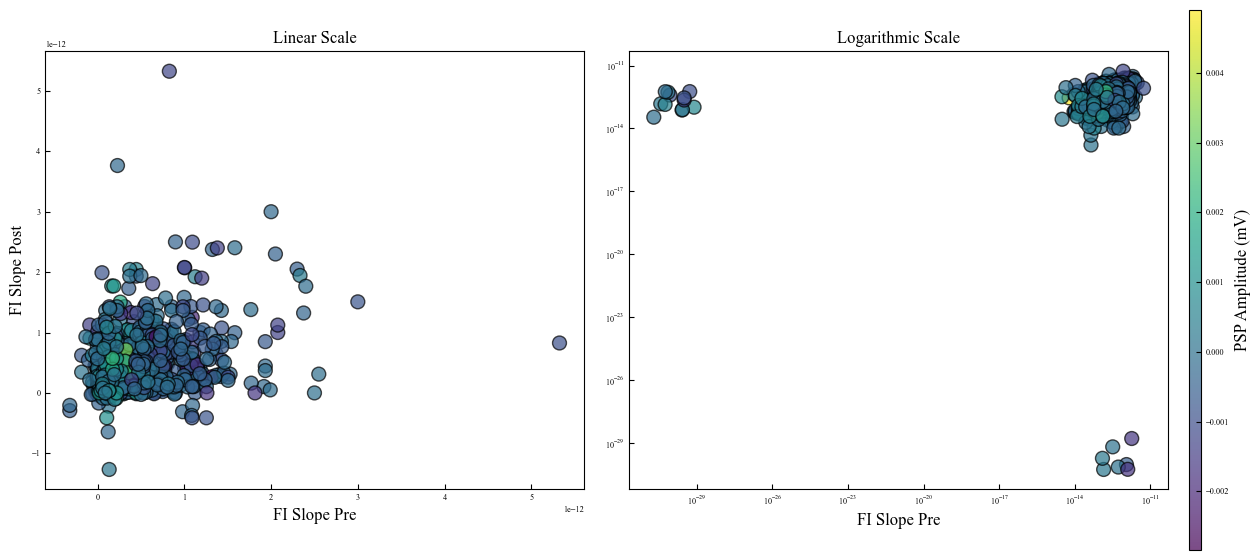

In [108]:
df_filtered = df_experiments.copy()

# Create the figure with two subplots without shared axes
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# First plot with linear scale
sc1 = axs[0].scatter(df_filtered['fi_slope_pre'], df_filtered['fi_slope_post'], 
                      c=np.log1p(df_filtered['psp_amplitude']), cmap='viridis', edgecolors='k', 
                      s=100, alpha=0.7)

axs[0].set_xlabel('FI Slope Pre')
axs[0].set_ylabel('FI Slope Post')
axs[0].set_title('Linear Scale')

# Second plot with logarithmic scale
sc2 = axs[1].scatter(df_filtered['fi_slope_pre'], df_filtered['fi_slope_post'], 
                      c=np.log1p(df_filtered['psp_amplitude']), cmap='viridis', edgecolors='k', 
                      s=100, alpha=0.7)
axs[1].set_xlabel('FI Slope Pre')
axs[1].set_title('Logarithmic Scale')
axs[1].set_xscale('log')
axs[1].set_yscale('log')

# Adjust the layout to leave space at the top
plt.tight_layout(rect=[0, 0, 1, 0.9])

# Create an additional axis for the colorbar at the top
cbar_ax = fig.add_axes([1, 0, 0.01, 0.9])
cbar = fig.colorbar(sc1, cax=cbar_ax, orientation='vertical')
cbar.set_label('PSP Amplitude (mV)')

plt.show()




## Without data transformation

In [123]:
from sklearn.cluster import KMeans

In [128]:


query = """ 
            SELECT 
                p.experiment_id,
                p.id AS pair_id,
                p.pre_cell_id, 
                p.post_cell_id, 
                syn.psp_amplitude,
                i_pre.fi_slope AS fi_slope_pre,
                i_post.fi_slope AS fi_slope_post
                


            FROM pair p

            INNER JOIN experiment e ON e.id = p.experiment_id

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id

            INNER JOIN synapse syn ON syn.pair_id = p.id

            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id

            -- Filter out what is relevant for us
            WHERE
                i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL
                AND syn.psp_amplitude IS NOT NULL

                --AND i_pre.fi_slope > 0
                --AND i_post.fi_slope > 0

                --p.has_synapse IS NOT NULL
                ; 
        """

df_experiments = pd.read_sql_query(query, con)

df_experiments


,experiment_id,pair_id,pre_cell_id,post_cell_id,psp_amplitude,fi_slope_pre,fi_slope_post
0,3271,102624,18608,18612,0.004912,5.952383e-15,2.881222e-13
1,3270,102619,18606,18607,0.000393,2.085229e-13,9.777069e-14
2,3274,102709,18625,18622,-0.000900,4.019802e-13,1.151387e-13
3,3502,108220,19758,19760,0.000111,2.379171e-13,7.093534e-14
4,3274,102675,18622,18625,0.000104,1.151387e-13,4.019802e-13
...,...,...,...,...,...,...,...
809,2326,76208,13574,13575,0.000145,5.792521e-13,1.807065e-13
810,2793,88588,15964,15961,-0.000026,1.914810e-13,3.033021e-13
811,5105,123616,24778,24781,-0.000198,8.018796e-13,9.525691e-14
812,5117,123712,24813,24814,0.000379,7.079645e-14,7.336674e-13


c:\Users\snrambo\AppData\Local\miniconda3\envs\aisynphys39\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


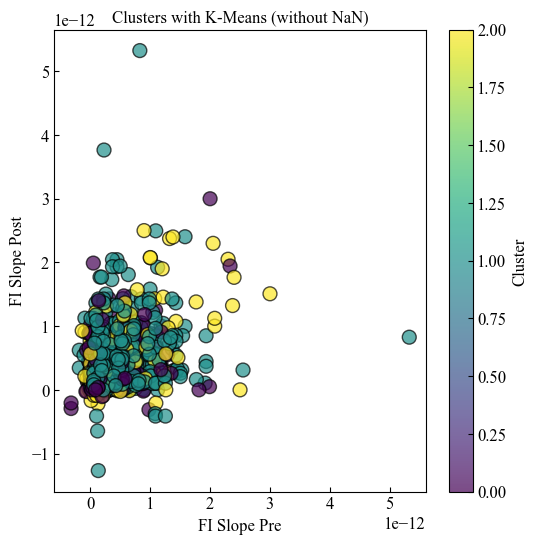

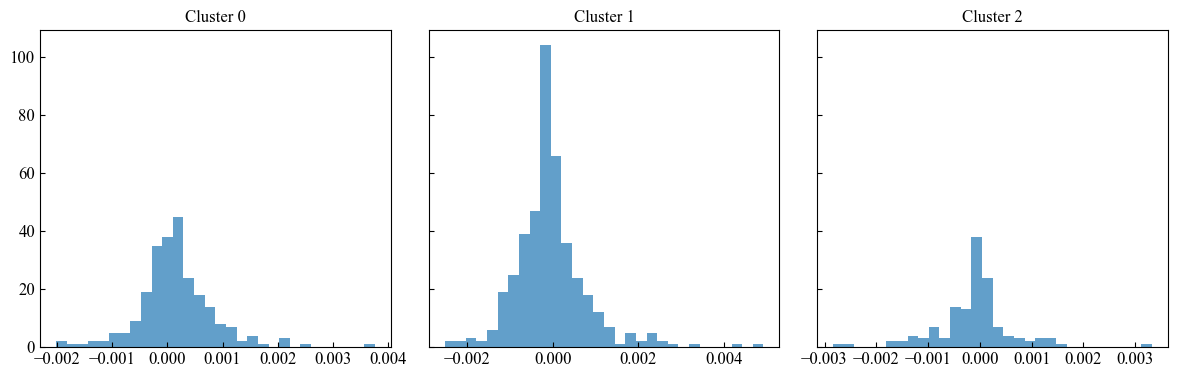

In [130]:
# Possible fix to threading warning
import os
os.environ["OMP_NUM_THREADS"] = "4"

# KMeans
from sklearn.cluster import KMeans

# KMeans: Each point is assigned to nearest center (cluster "means")
# Nearest neighbor
# Update
# Repeat until convergence

# Select the columns needed for clustering

df_no_nan = df_experiments.copy()

# Convert to numpy array for K-Means
X = df_no_nan.values

# Apply K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X)

# Create a 'cluster' column in df_no_nan
df_no_nan['cluster'] = kmeans.labels_

df_result_exclude = df_no_nan.copy()
df_result_exclude['cluster'] = None
df_result_exclude.loc[df_no_nan.index, 'cluster'] = df_no_nan['cluster']

# Plot to verify
plt.figure(figsize=(6, 6))
sc = plt.scatter(
    df_no_nan['fi_slope_pre'], 
    df_no_nan['fi_slope_post'], 
    c=df_no_nan['cluster'], 
    cmap='viridis', 
    edgecolors='k', 
    s=100, 
    alpha=0.7
)

plt.xlabel('FI Slope Pre')
plt.ylabel('FI Slope Post')
plt.title('Clusters with K-Means (without NaN)')
plt.colorbar(sc, label='Cluster')
plt.show()

# Finally, make histograms of psp_amplitude for each cluster
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for i in range(3):
    cluster_data = df_result_exclude[df_result_exclude['cluster'] == i]
    axs[i].hist(cluster_data['psp_amplitude'], bins=30, alpha=0.7)
    axs[i].set_title(f'Cluster {i}')

plt.tight_layout()
plt.show()



## With data transformation

In [8]:
query = """ 
            SELECT 
                p.experiment_id,
                p.id AS pair_id,
                p.pre_cell_id, 
                p.post_cell_id, 
                syn.psp_amplitude,
                i_pre.fi_slope AS fi_slope_pre,
                i_post.fi_slope AS fi_slope_post
                


            FROM pair p

            INNER JOIN experiment e ON e.id = p.experiment_id

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id

            INNER JOIN synapse syn ON syn.pair_id = p.id

            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id

            -- Filter out what is relevant for us
            WHERE
                i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL
                AND syn.psp_amplitude IS NOT NULL

                AND i_pre.fi_slope > 0
                AND i_post.fi_slope > 0

                --p.has_synapse IS NOT NULL
                ; 
        """

df = pd.read_sql_query(query, con)

df


,experiment_id,pair_id,pre_cell_id,post_cell_id,psp_amplitude,fi_slope_pre,fi_slope_post
0,3271,102624,18608,18612,0.004912,5.952383e-15,2.881222e-13
1,3270,102619,18606,18607,0.000393,2.085229e-13,9.777069e-14
2,3274,102709,18625,18622,-0.000900,4.019802e-13,1.151387e-13
3,3502,108220,19758,19760,0.000111,2.379171e-13,7.093534e-14
4,3274,102675,18622,18625,0.000104,1.151387e-13,4.019802e-13
...,...,...,...,...,...,...,...
731,2326,76208,13574,13575,0.000145,5.792521e-13,1.807065e-13
732,2793,88588,15964,15961,-0.000026,1.914810e-13,3.033021e-13
733,5105,123616,24778,24781,-0.000198,8.018796e-13,9.525691e-14
734,5117,123712,24813,24814,0.000379,7.079645e-14,7.336674e-13


c:\Users\snrambo\AppData\Local\miniconda3\envs\aisynphys39\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\snrambo\AppData\Local\Temp\ipykernel_15140\736009250.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(clusters))


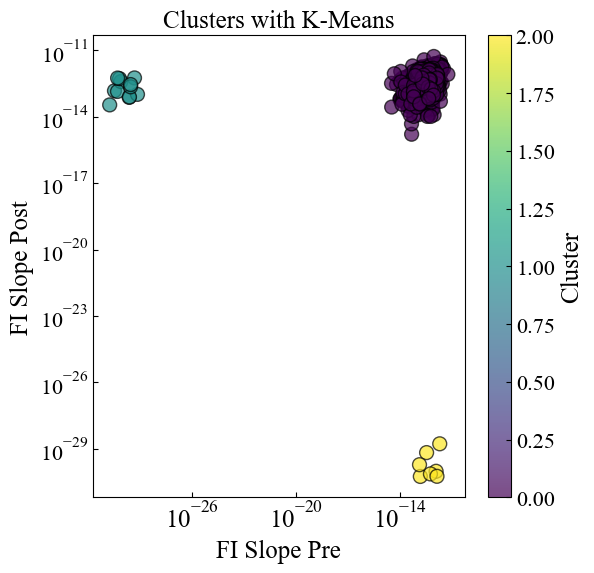

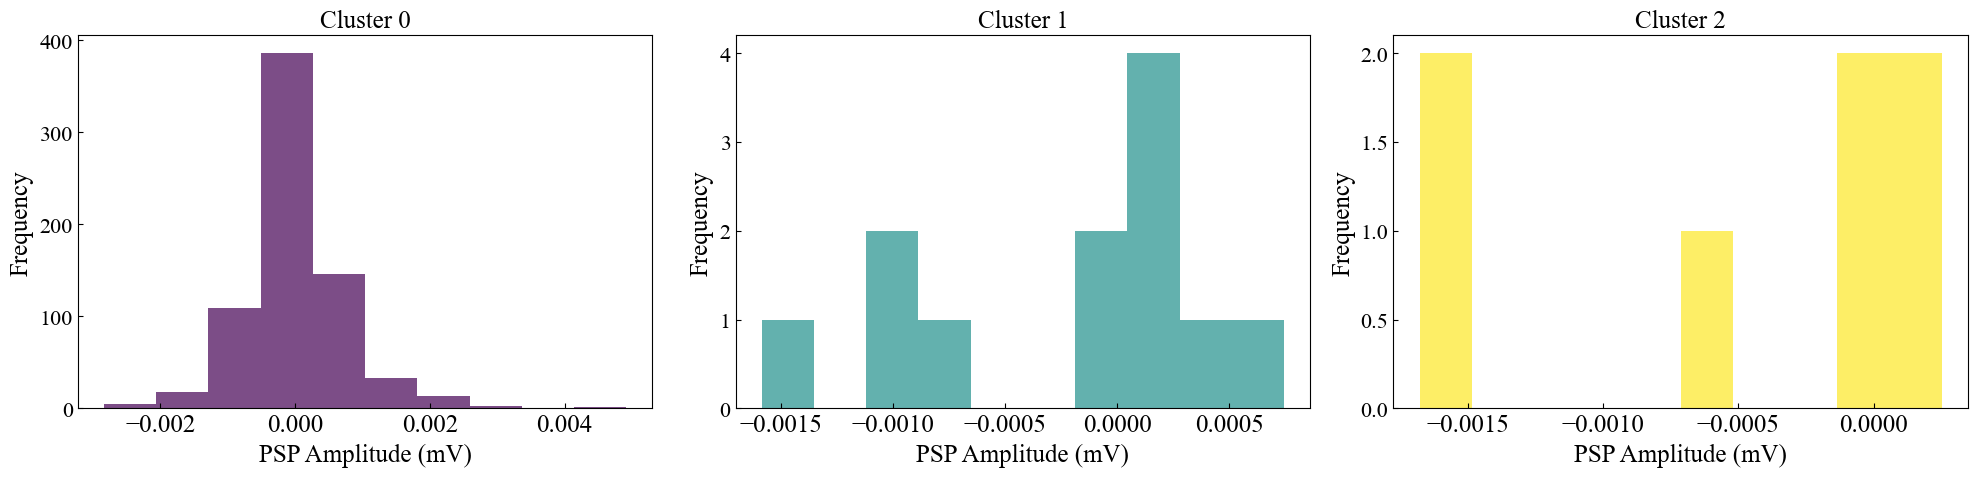

In [14]:
# Possible fix to threading warning
import os
os.environ["OMP_NUM_THREADS"] = "4"

# KMeans
from sklearn.cluster import KMeans

# KMeans: Each point is assigned to nearest center (cluster "means")
# Nearest neighbor
# Update
# Repeat until convergence
import matplotlib.cm as cm

df_experiments = df.copy()

# 2) Create logarithmic version of fi_slope_pre and fi_slope_post
df_clean_log = df_experiments[['fi_slope_pre', 'fi_slope_post']].apply(np.log10)

# 3) Apply K-Means on logarithmic data
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(df_clean_log)

# Save the cluster labels in the original DataFrame (df_clean)
df_experiments['cluster'] = kmeans.labels_

# Get unique clusters
clusters = sorted(df_experiments['cluster'].unique())

# Get the colormap used in the scatter plot
cmap = cm.get_cmap('viridis', len(clusters))
colors = [cmap(i) for i in range(len(clusters))]

# 4) Plot in log scale on axes
plt.figure(figsize=(6, 6))
sc = plt.scatter(
    df_experiments['fi_slope_pre'], 
    df_experiments['fi_slope_post'], 
    c=df_experiments['cluster'], 
    cmap='viridis', 
    edgecolors='k', 
    s=100, 
    alpha=0.7
)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('FI Slope Pre')
plt.ylabel('FI Slope Post')
plt.title('Clusters with K-Means')
cbar = plt.colorbar(sc)
cbar.set_label('Cluster')
plt.show()

# Create a subplot for each cluster
fig, axs = plt.subplots(1, len(clusters), figsize=(20, 5))

for i, cl in enumerate(clusters):
    # Select data from cluster i
    cluster_data = df_experiments[df_experiments['cluster'] == cl]['psp_amplitude']
    axs[i].hist(cluster_data, alpha=0.7, color=colors[i])
    axs[i].set_title(f'Cluster {cl}')
    axs[i].set_xlabel('PSP Amplitude (mV)')
    axs[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [20]:
# SQL query to retrieve the desired info

query = """ 
            SELECT 
                p.experiment_id,
                COUNT(*) AS total_pairs,
                SUM(p.has_synapse) AS num_synapses,
                COUNT(*) - SUM(p.has_synapse) AS num_no_synapses


            FROM pair p

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id


            WHERE 
                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- No null values in synapse and cell classes
                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'
                
            GROUP BY p.experiment_id
            HAVING num_synapses != 0;
        """

df_onlysynapse = pd.read_sql_query(query, con)

df_onlysynapse

,experiment_id,total_pairs,num_synapses,num_no_synapses
0,64,6,1,5
1,66,6,1,5
2,67,20,7,13
3,79,42,1,41
4,99,42,3,39
...,...,...,...,...
1081,5264,12,1,11
1082,5265,6,4,2
1083,5266,1,1,0
1084,5268,2,1,1


In [19]:
print(1086 + 1355)

2441


To look for where it is above some number of synapses we can use having:

In [57]:
# SQL query to retrieve the desired info

query = """ 
            SELECT 
                p.experiment_id,
                COUNT(*) AS total_pairs,
                SUM(p.has_synapse) AS num_synapses,
                COUNT(*) - SUM(p.has_synapse) AS num_no_synapses


            FROM pair p

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id


            WHERE 
                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- No null values in synapse and cell classes
                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'
                
            GROUP BY p.experiment_id
            HAVING num_synapses > 10;
        """

df_synapses = pd.read_sql_query(query, con)

df_synapses


,experiment_id,total_pairs,num_synapses,num_no_synapses
0,1504,42,11,31
1,1864,30,11,19
2,2771,30,11,19
3,2808,20,12,8
4,3172,56,19,37
5,3228,30,12,18
6,3262,42,11,31


# Motif stuff

* Preprocessing to get only relevant data
    * Know when a synapse occurred or not
    * Ensure we inclue only when we could have possibly observed a motif


loop over the list of observed synapses and count:

- **Reciprocal motifs**: if both A→B and B→A exist.
- **Divergent motifs**: one neuron projecting to two.
- **Convergent motifs**: two neurons projecting to the same one.
- **Chain motifs**: A→B→C.

avoid counting the same motif multiple times (e.g., by imposing a condition such as `pre1 < pre2`).


**Motif score**
To quantify how "special" a motif is: z-score **τ**.  
if a given motif is **more or less frequent than expected by chance**, assuming synapses are formed independently.


τ = (p_motif - p²) / σ²

- `p_motif` is the observed frequency of the motif.
- `p` is the overall connection probability.
- `σ² = p(1 - p)` is the variance under a Bernoulli model.

## Synapse statistics

The requirements I enforce with this SQL query is

* Synapses
* Mouse
* Target region VisP
* No NaN synapse
* No NaN in pre_cell and post_cell
* Not mixed pre_cell

In [56]:
# Nested subquery to retrieve global statistics



query = """ 
    WITH experiment_stats AS (
            SELECT 
                p.experiment_id,
                COUNT(*) AS total_pairs,
                SUM(p.has_synapse) AS num_synapses,
                COUNT(*) - SUM(p.has_synapse) AS num_no_synapses


            FROM pair p

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id
            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
            --INNER JOIN synapse syn ON syn.pair_id = p.id


            WHERE 
                -- Brain specs
                s.species = 'mouse'
                AND e.target_region = 'VisP' 

                -- Requirements on data
                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'

                AND i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL

                
            GROUP BY p.experiment_id
        )
        SELECT
            SUM(total_pairs) AS total_pairs_measured,
            SUM(num_synapses) AS total_synapses,
            SUM(num_no_synapses) AS total_no_synapses,
            COUNT(*) AS total_experiments,
            SUM(CASE WHEN num_synapses >= 3 THEN 1 ELSE 0 END) AS experiments_with_at_least_3_synapses,
            SUM(CASE WHEN num_synapses >= 2 THEN 1 ELSE 0 END) AS experiments_with_at_least_2_synapses,
            SUM(CASE WHEN num_synapses = 0 THEN 1 ELSE 0 END) AS experiments_with_no_synapses
        FROM experiment_stats;
        """

df_global_stats = pd.read_sql_query(query, con)

df_global_stats


,total_pairs_measured,total_synapses,total_no_synapses,total_experiments,experiments_with_at_least_3_synapses,experiments_with_at_least_2_synapses,experiments_with_no_synapses
0,7691,768,6923,872,90,190,529


In [61]:
# SQL query to retrieve the valid experiments

query = """ 
            SELECT 
                p.experiment_id,
                p.pre_cell_id, 
                p.post_cell_id, 
                pre.cell_class AS pre_cell_class,
                post.cell_class AS post_cell_class,
                p.has_synapse 

            FROM pair p

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id
            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
            --INNER JOIN synapse syn ON syn.pair_id = p.id


            WHERE 

                -- Brain specs
                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- Requirements on data
                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'
                AND i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL
                ; 
        """

df_valid_experiments = pd.read_sql_query(query, con)

df_valid_experiments


,experiment_id,pre_cell_id,post_cell_id,pre_cell_class,post_cell_class,has_synapse
0,600,4133,4138,in,in,0
1,600,4133,4140,in,ex,0
2,600,4133,4142,in,in,0
3,600,4138,4133,in,in,0
4,600,4138,4140,in,ex,1
...,...,...,...,...,...,...
7686,5108,24790,24791,ex,in,1
7687,5108,24791,24790,in,ex,1
7688,5110,24799,24798,in,mixed,0
7689,5117,24813,24814,ex,in,1


In [71]:

# SQL query to retrieve the desired info

query = """ 
            SELECT 
                --e.id AS experiment_id, 
                p.experiment_id,
                p.pre_cell_id, 
                p.post_cell_id, 
                p.has_synapse, 
                --syn.id AS synapse_id,
                pre.cell_class AS pre_cell_class,
                post.cell_class AS post_cell_class,
                i_pre.fi_slope AS fi_slope_pre,
                i_post.fi_slope AS fi_slope_post

            FROM pair p

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id
            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
            --INNER JOIN synapse syn ON syn.pair_id = p.id

            WHERE 
                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- No null values in synapse and cell classes
                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL

                AND i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'
                ; 
        """

df_valid_experiments = pd.read_sql_query(query, con)

df_valid_experiments

# print(len(df_valid_experiments["experiment_id"].unique()))  # unique experiments


,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post
0,600,4133,4138,0,in,in,8.230065e-13,1.105000e-12
1,600,4133,4140,0,in,ex,8.230065e-13,1.131452e-13
2,600,4133,4142,0,in,in,8.230065e-13,8.820777e-13
3,600,4138,4133,0,in,in,1.105000e-12,8.230065e-13
4,600,4138,4140,1,in,ex,1.105000e-12,1.131452e-13
...,...,...,...,...,...,...,...,...
7686,5108,24790,24791,1,ex,in,6.639170e-14,4.244768e-13
7687,5108,24791,24790,1,in,ex,4.244768e-13,6.639170e-14
7688,5110,24799,24798,0,in,mixed,5.590663e-13,3.932555e-13
7689,5117,24813,24814,1,ex,in,7.079645e-14,7.336674e-13


In [65]:
print(len(df_valid_experiments["experiment_id"].unique()))  # unique experiments

872


In [66]:
# Valid experiment ids

# SQL query to retrieve the valid experiments with k data points

cur.execute(""" 
    
    -- Filter experiments that meet the requirements

    WITH valid_experiments AS (
        SELECT 
            p.experiment_id

        FROM pair p

        INNER JOIN cell pre ON p.pre_cell_id = pre.id
        INNER JOIN cell post ON p.post_cell_id = post.id
        INNER JOIN experiment e ON e.id = p.experiment_id
        INNER JOIN slice s ON e.slice_id = s.id
        INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
        INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
        --INNER JOIN synapse syn ON syn.pair_id = p.id

        WHERE 

            -- Brain specs
            s.species = 'mouse' 
            AND e.target_region = 'VisP' 

            -- Requirements on data
            AND p.has_synapse IS NOT NULL
            AND pre.cell_class IS NOT NULL
            AND post.cell_class IS NOT NULL
            AND pre.cell_class != 'mixed'
            AND i_pre.fi_slope IS NOT NULL
            AND i_post.fi_slope IS NOT NULL
    )

    -- Then keep only experiment ids from those with more than or equal to k rows
    
    SELECT experiment_id
    FROM valid_experiments
    GROUP BY experiment_id
    HAVING COUNT(*) >= 3; 
        """)

experiment_ids = cur.fetchall()

print(experiment_ids)
print(len(experiment_ids))

[(600,), (605,), (606,), (610,), (614,), (623,), (651,), (688,), (689,), (692,), (699,), (700,), (727,), (729,), (731,), (732,), (739,), (770,), (771,), (772,), (779,), (780,), (793,), (824,), (825,), (841,), (850,), (851,), (852,), (858,), (862,), (865,), (875,), (898,), (900,), (901,), (934,), (939,), (940,), (1003,), (1008,), (1035,), (1036,), (1069,), (1075,), (1077,), (1079,), (1117,), (1121,), (1122,), (1123,), (1124,), (1173,), (1187,), (1202,), (1209,), (1218,), (1221,), (1223,), (1297,), (1306,), (1324,), (1330,), (1343,), (1370,), (1374,), (1378,), (1379,), (1408,), (1424,), (1436,), (1442,), (1443,), (1448,), (1454,), (1455,), (1461,), (1462,), (1471,), (1472,), (1473,), (1476,), (1477,), (1478,), (1485,), (1486,), (1488,), (1489,), (1494,), (1497,), (1503,), (1504,), (1505,), (1507,), (1511,), (1515,), (1521,), (1523,), (1525,), (1527,), (1528,), (1530,), (1531,), (1532,), (1537,), (1542,), (1544,), (1545,), (1550,), (1551,), (1556,), (1560,), (1562,), (1565,), (1567,), (15

## Compute motifs

Can take PSP matrices and compute motifs for current experiments, send to  motifs()

In [ ]:
# Convert the dataframe to a numpy array
psp_matrix_numpy = df_psp_matrix.values

def motifs(w,N):
   '''
   Takes the psp matrix, and how many neurons, and perform motif calculations
   
   '''
   w=w-np.mean(w)
   ww=np.matmul(w,w)
   wtw=np.matmul(w.T,w)
   wwt=np.matmul(w,w.T)
   sigma2=np.trace(wwt)/N
   tau_rec=np.trace(ww)
   tau_rec/=sigma2*N
   tau_div=np.sum(wwt)-np.trace(wwt)
   tau_div/=sigma2*N*(N-1)
   tau_con=np.sum(wtw)-np.trace(wtw)
   tau_con/=sigma2*N*(N-1)
   tau_chn=2*(np.sum(ww)-np.trace(ww))
   tau_chn/=sigma2*N*(N-1)
   return tau_rec,tau_div,tau_con,tau_chn

   


# Modify the output print to get values as simple floats
result = motifs(psp_matrix_numpy, len(all_cells))
print(f"tau_rec: {result[0].item():.5f}, tau_div: {result[1].item():.5f}, tau_con: {result[2].item():.5f}, tau_chn: {result[3].item():.5f}")

### Count how many motifs could have possibly been observed

In [68]:
from itertools import combinations
#### Functions to compute motifs


# Counts whether the motifs could have appeared
def count_reciprocal(df):
    # Maps whether synapses exist in each direction
    connectivity = set(map(tuple, df[['pre_cell_id','post_cell_id']].values))
    rec = 0

    # Iterate over unordered combinations of pairs of neurons (take combinations, then count pairs of connections only once)

    neurons = df['pre_cell_id'].unique()
    for a, b in combinations(neurons, 2):
        # Does A→B and B→A exist?
        if (a,b) in connectivity and (b,a) in connectivity:
            rec += 1

    return rec


def count_divergent(df):
    div = 0
    # For each presynaptic, look at its posts and choose pairs of posts
    for pre, subdf in df.groupby('pre_cell_id'):
        posts = subdf['post_cell_id'].unique()
        for post1, post2 in combinations(posts, 2):
            if post1 == post2 or post1 == pre or post2 == pre:
                continue
            div += 1

    return div


def count_convergent(df):
    con = 0
    # For each postsynaptic, look at its pres and choose pairs of pres
    for post, subdf in df.groupby('post_cell_id'):
        pres = subdf['pre_cell_id'].unique()
        for pre1, pre2 in combinations(pres, 2):
            if pre1 == post or pre2 == post:
                continue
            con += 1

    return con


def count_chain(df):
    chn = 0
    # Gamma is an intermediate node: it appears as a post in one connection and a pre in another
    for gamma in set(df['pre_cell_id']).intersection(df['post_cell_id']):
        ins  = df[df['post_cell_id']==gamma]  # conexiones pre→gamma
        outs = df[df['pre_cell_id']==gamma]   # conexiones gamma→post
        pres = ins['pre_cell_id'].unique()
        posts = outs['post_cell_id'].unique()
        # Combina cada pre con cada post
        for pre, post in ((p, q) for p in pres for q in posts):
            if pre in (gamma, post) or post in (gamma, pre):
                continue
            chn += 1

    return chn

print(count_reciprocal(df_valid_experiments))
print(count_divergent(df_valid_experiments))
print(count_convergent(df_valid_experiments))
print(count_chain(df_valid_experiments))



3731
9736
9470
18943


### Compute motifs

In [69]:
def safe_divide(n, d):
    '''Returns np.nan if the denominator is zero'''
    return n / d if d != 0 else np.nan

def compute_tau(count_motif, count_possible, sigma2, p):
    '''
    Computes tau

    Parameters:
    --------------------
    count_motif     :   counts of a motif
    count_possible  :   count of possible
    p               :   overall connection probability
    sigma2          :   variance under Bernoulli

    Returns:
    --------------------
    tau, given by
        p_motif     :   frequency of motifs, given by motif count / possible counts
        p           :   given by how many synapses / total measured
        sigma2      :   p * (1-p)
    '''
    p_motif = safe_divide(count_motif,count_possible)

    return safe_divide((p_motif-p**2),sigma2)

def compute_motifs(df):
    '''
    To calculate the possible motifs we take the dataframe where the 'has_synapse' column takes values 0 or 1. that is, the measurement was performed and it was determined whether there are ('has_synapse' = 1) or no ('has_synapse' = 0) synapses. Unvalid experiments are already filtered away.
    '''

    # Number of connections where a motif could have appeared
    possible_rec = count_reciprocal(df)
    possible_div = count_divergent(df)
    possible_con = count_convergent(df)
    possible_chn = count_chain(df)

    # Use subset where has_synapse == 1 to calculate the number of motifs that are actually present

    df_syn = df[df['has_synapse'] == 1]

    rec_count = count_reciprocal(df_syn)
    div_count = count_divergent(df_syn)
    con_count = count_convergent(df_syn)
    chn_count = count_chain(df_syn)


    if len(df_syn) == 0:
        return (np.nan, np.nan, np.nan, np.nan)
    
    p = len(df_syn) / len(df)  # calculate p
    
    sigma2 = p * (1 - p)  # calculate sigma^2

    tau_rec = compute_tau(rec_count, possible_rec, sigma2, p)
    tau_div = compute_tau(div_count, possible_div, sigma2, p)
    tau_con = compute_tau(con_count, possible_con, sigma2, p)
    tau_chn = compute_tau(chn_count, possible_chn, sigma2, p)
   

    return tau_rec, tau_div, tau_con, tau_chn



In [ ]:
# V2

import random
# Data structure to store motifs

########## Get valid experiment ids

query = """ 
            SELECT 
                --e.id AS experiment_id, 
                p.experiment_id,
                p.pre_cell_id, 
                p.post_cell_id, 
                p.has_synapse, 
                --syn.id AS synapse_id,
                pre.cell_class AS pre_cell_class,
                post.cell_class AS post_cell_class,
                i_pre.fi_slope AS fi_slope_pre,
                i_post.fi_slope AS fi_slope_post

            FROM pair p

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id
            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
            --INNER JOIN synapse syn ON syn.pair_id = p.id

            WHERE 
                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- No null values in synapse and cell classes
                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL

                AND i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'
                ; 
        """

df_valid_experiments = pd.read_sql_query(query, con)


# SQL query to retrieve the experiment ids from valid experiments with k data points

cur.execute(""" 
    
    -- Filter experiments that meet the requirements

    WITH valid_experiments AS (
        SELECT 
            p.experiment_id

        FROM pair p

        INNER JOIN cell pre ON p.pre_cell_id = pre.id
        INNER JOIN cell post ON p.post_cell_id = post.id
        INNER JOIN experiment e ON e.id = p.experiment_id
        INNER JOIN slice s ON e.slice_id = s.id
        INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
        INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
        --INNER JOIN synapse syn ON syn.pair_id = p.id

        WHERE 

            -- Brain specs
            s.species = 'mouse' 
            AND e.target_region = 'VisP' 

            -- Requirements on data
            AND p.has_synapse IS NOT NULL
            AND pre.cell_class IS NOT NULL
            AND post.cell_class IS NOT NULL
            AND pre.cell_class != 'mixed'
            AND i_pre.fi_slope IS NOT NULL
            AND i_post.fi_slope IS NOT NULL
    )

    -- Then keep only experiment ids from those with more than or equal to k rows
    
    SELECT experiment_id
    FROM valid_experiments
    GROUP BY experiment_id
    HAVING COUNT(*) >= 3; 
        """)

experiment_ids_tuple = cur.fetchall()  # fetches all experiment ids
# exp_ids = [t[0] for t in experiment_ids_tuple]  # convert each element from tuple to integer
nboot=10
iexp = [t[0] for t in experiment_ids_tuple]  # convert each element from tuple to integer
print(iexp)
print(len(iexp))


##########
# Choose only a few experiments?? Might change later

motifs_data = {
    'experiment_id': [],
    'motif_rec': [],
    'motif_div': [],
    'motif_con': [],
    'motif_chn': []
}

iterations = 10
k = 10



# selected_ids = random.sample(exp_ids, k)
# selected_ids = exp_ids[np.random.choice(len(exp_ids), size=int(len(exp_ids)*0.1), replace=False)] # take out 10% of experiments from total experiments

# selected_ids = [exp_ids[i] for i in np.random.choice(len(exp_ids), size=int(len(exp_ids)*0.1), replace=False)]
import random

# selected_ids = random.sample(exp_ids, int(len(exp_ids) * 0.1))
# print(selected_ids)



for iboot in range(nboot):
    # For up to 10
    iexp_i=iexp[np.random.choice(len(iexp), size=int(len(iexp)*0.1), replace=False)] # take out 10% of experiments from total experiments
    print(iboot)

    # TODO

    # Containers
    av_rec=[]
    av_div=[]
    av_con=[]
    av_chn=[]


    for i in iexp_i:

        df_exp = df_valid_experiments[df_valid_experiments['experiment_id']==i]

        pre_ids = df_exp['pre_cell_id'].unique()
        post_ids = df_exp['post_cell_id'].unique()
        neuronas_total = np.unique(np.concatenate((pre_ids, post_ids)))
        n = len(neuronas_total)

        possible_synapses = n * (n - 1)

        measured_synapses = df_exp[df_exp['pre_cell_id'] != df_exp['post_cell_id']]
        unique_synapses = measured_synapses[['pre_cell_id', 'post_cell_id']].drop_duplicates()

        if len(unique_synapses) != possible_synapses:
            continue

        motif_rec, motif_div, motif_con, motif_chn = compute_motifs(df_exp)

        av_rec.append(motif_rec)
        av_div.append(motif_div)
        av_con.append(motif_con)
        av_chn.append(motif_chn)

    # Compute average of each motif across experiments
    av_rec=np.nanmean(np.array(av_rec))
    av_div=np.nanmean(np.array(av_div))
    av_con=np.nanmean(np.array(av_con))
    av_chn=np.nanmean(np.array(av_chn))

    motifs_data['motif_rec'].append(av_rec)
    motifs_data['motif_div'].append(av_div)
    motifs_data['motif_con'].append(av_con)
    motifs_data['motif_chn'].append(av_chn)

df_motifs = pd.DataFrame(motifs_data)
print(df_motifs)
plt.figure(figsize=(8, 5)) 
for motif in ['motif_rec', 'motif_div', 'motif_con', 'motif_chn']:
    data = df_motifs[motif].dropna()
    print(f"{motif}: {len(data)} values")

    if len(data) == 0:
        # print(f"No hay datos para {motif}, se salta el gráfico.")
        print(f"No data for motif {motif}, graph skipped.")
        continue

    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=20, color='skyblue', edgecolor='black')
    plt.title(f"Histogram {motif}")
    plt.xlabel('Motif values')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    plt.show()



[600, 605, 606, 610, 614, 623, 651, 688, 689, 692, 699, 700, 727, 729, 731, 732, 739, 770, 771, 772, 779, 780, 793, 824, 825, 841, 850, 851, 852, 858, 862, 865, 875, 898, 900, 901, 934, 939, 940, 1003, 1008, 1035, 1036, 1069, 1075, 1077, 1079, 1117, 1121, 1122, 1123, 1124, 1173, 1187, 1202, 1209, 1218, 1221, 1223, 1297, 1306, 1324, 1330, 1343, 1370, 1374, 1378, 1379, 1408, 1424, 1436, 1442, 1443, 1448, 1454, 1455, 1461, 1462, 1471, 1472, 1473, 1476, 1477, 1478, 1485, 1486, 1488, 1489, 1494, 1497, 1503, 1504, 1505, 1507, 1511, 1515, 1521, 1523, 1525, 1527, 1528, 1530, 1531, 1532, 1537, 1542, 1544, 1545, 1550, 1551, 1556, 1560, 1562, 1565, 1567, 1572, 1577, 1579, 1580, 1583, 1584, 1585, 1586, 1587, 1593, 1600, 1612, 1622, 1630, 1632, 1636, 1643, 1655, 1656, 1668, 1671, 1673, 1674, 1682, 1686, 1688, 1692, 1693, 1694, 1695, 1698, 1705, 1718, 1722, 1735, 1739, 1744, 1746, 1749, 1751, 1752, 1753, 1756, 1758, 1759, 1761, 1763, 1774, 1775, 1776, 1778, 1779, 1782, 1783, 1785, 1787, 1789, 1790, 

TypeError: only integer scalar arrays can be converted to a scalar index

[600, 605, 606, 610, 614, 623, 651, 688, 689, 692, 699, 700, 727, 729, 731, 732, 739, 770, 771, 772, 779, 780, 793, 824, 825, 841, 850, 851, 852, 858, 862, 865, 875, 898, 900, 901, 934, 939, 940, 1003, 1008, 1035, 1036, 1069, 1075, 1077, 1079, 1117, 1121, 1122, 1123, 1124, 1173, 1187, 1202, 1209, 1218, 1221, 1223, 1297, 1306, 1324, 1330, 1343, 1370, 1374, 1378, 1379, 1408, 1424, 1436, 1442, 1443, 1448, 1454, 1455, 1461, 1462, 1471, 1472, 1473, 1476, 1477, 1478, 1485, 1486, 1488, 1489, 1494, 1497, 1503, 1504, 1505, 1507, 1511, 1515, 1521, 1523, 1525, 1527, 1528, 1530, 1531, 1532, 1537, 1542, 1544, 1545, 1550, 1551, 1556, 1560, 1562, 1565, 1567, 1572, 1577, 1579, 1580, 1583, 1584, 1585, 1586, 1587, 1593, 1600, 1612, 1622, 1630, 1632, 1636, 1643, 1655, 1656, 1668, 1671, 1673, 1674, 1682, 1686, 1688, 1692, 1693, 1694, 1695, 1698, 1705, 1718, 1722, 1735, 1739, 1744, 1746, 1749, 1751, 1752, 1753, 1756, 1758, 1759, 1761, 1763, 1774, 1775, 1776, 1778, 1779, 1782, 1783, 1785, 1787, 1789, 1790, 

<Figure size 800x500 with 0 Axes>

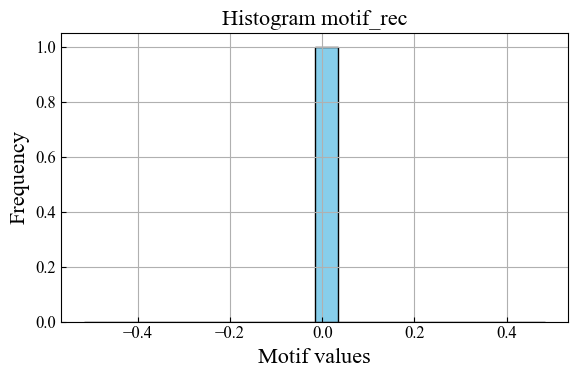

motif_div: 1 values


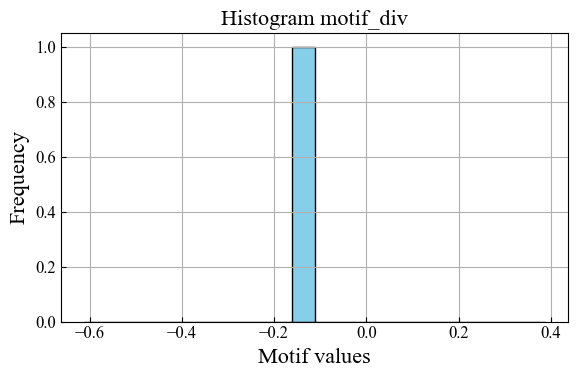

motif_con: 1 values


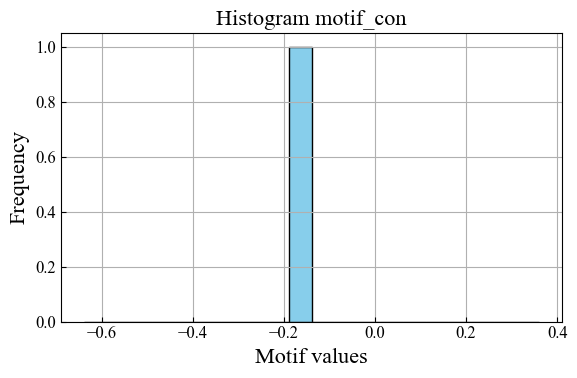

motif_chn: 1 values


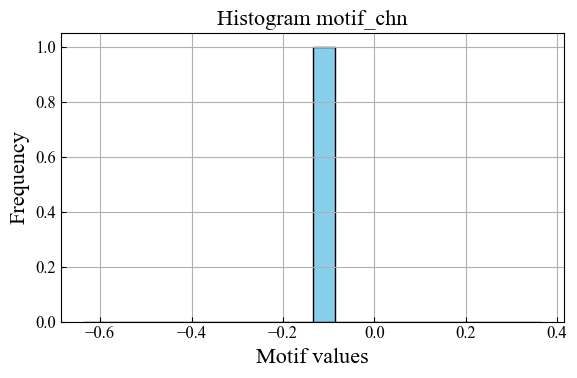

In [ ]:
# V1
import random
# Data structure to store motifs

########## Get valid experiment ids

query = """ 
            SELECT 
                --e.id AS experiment_id, 
                p.experiment_id,
                p.pre_cell_id, 
                p.post_cell_id, 
                p.has_synapse, 
                --syn.id AS synapse_id,
                pre.cell_class AS pre_cell_class,
                post.cell_class AS post_cell_class,
                i_pre.fi_slope AS fi_slope_pre,
                i_post.fi_slope AS fi_slope_post

            FROM pair p

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id
            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
            --INNER JOIN synapse syn ON syn.pair_id = p.id

            WHERE 
                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- No null values in synapse and cell classes
                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL

                AND i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'
                ; 
        """

df_valid_experiments = pd.read_sql_query(query, con)


# SQL query to retrieve the experiment ids from valid experiments with k data points

cur.execute(""" 
    
    -- Filter experiments that meet the requirements

    WITH valid_experiments AS (
        SELECT 
            p.experiment_id

        FROM pair p

        INNER JOIN cell pre ON p.pre_cell_id = pre.id
        INNER JOIN cell post ON p.post_cell_id = post.id
        INNER JOIN experiment e ON e.id = p.experiment_id
        INNER JOIN slice s ON e.slice_id = s.id
        INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
        INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
        --INNER JOIN synapse syn ON syn.pair_id = p.id

        WHERE 

            -- Brain specs
            s.species = 'mouse' 
            AND e.target_region = 'VisP' 

            -- Requirements on data
            AND p.has_synapse IS NOT NULL
            AND pre.cell_class IS NOT NULL
            AND post.cell_class IS NOT NULL
            AND pre.cell_class != 'mixed'
            AND i_pre.fi_slope IS NOT NULL
            AND i_post.fi_slope IS NOT NULL
    )

    -- Then keep only experiment ids from those with more than or equal to k rows
    
    SELECT experiment_id
    FROM valid_experiments
    GROUP BY experiment_id
    HAVING COUNT(*) >= 3; 
        """)

experiment_ids_tuple = cur.fetchall()  # fetches all experiment ids
exp_ids = [t[0] for t in experiment_ids_tuple]  # convert each element from tuple to integer
print(exp_ids)
print(len(exp_ids))


##########
# Choose only a few experiments?? Might change later

motifs_data = {
    # 'experiment_id': [],
    'motif_rec': [],
    'motif_div': [],
    'motif_con': [],
    'motif_chn': []
}

iterations = 10
k = 10
# selected_ids = random.sample(exp_ids, k)
# selected_ids = exp_ids[np.random.choice(len(exp_ids), size=int(len(exp_ids)*0.1), replace=False)] # take out 10% of experiments from total experiments

# selected_ids = [exp_ids[i] for i in np.random.choice(len(exp_ids), size=int(len(exp_ids)*0.1), replace=False)]
import random

selected_ids = random.sample(exp_ids, int(len(exp_ids) * 0.1))
# print(selected_ids)

# Containers
av_rec=[]
av_div=[]
av_con=[]
av_chn=[]
for i in selected_ids:

    df_exp = df_valid_experiments[df_valid_experiments['experiment_id']==i]

    pre_ids = df_exp['pre_cell_id'].unique()
    post_ids = df_exp['post_cell_id'].unique()
    neuronas_total = np.unique(np.concatenate((pre_ids, post_ids)))
    n = len(neuronas_total)

    possible_synapses = n * (n - 1)

    measured_synapses = df_exp[df_exp['pre_cell_id'] != df_exp['post_cell_id']]
    unique_synapses = measured_synapses[['pre_cell_id', 'post_cell_id']].drop_duplicates()

    if len(unique_synapses) != possible_synapses:
        continue

    motif_rec, motif_div, motif_con, motif_chn = compute_motifs(df_exp)

    av_rec.append(motif_rec)
    av_div.append(motif_div)
    av_con.append(motif_con)
    av_chn.append(motif_chn)

# Compute average of each motif across experiments
av_rec=np.nanmean(np.array(av_rec))
av_div=np.nanmean(np.array(av_div))
av_con=np.nanmean(np.array(av_con))
av_chn=np.nanmean(np.array(av_chn))

motifs_data['motif_rec'].append(av_rec)
motifs_data['motif_div'].append(av_div)
motifs_data['motif_con'].append(av_con)
motifs_data['motif_chn'].append(av_chn)

df_motifs = pd.DataFrame(motifs_data)
print(df_motifs)
plt.figure(figsize=(8, 5)) 
for motif in ['motif_rec', 'motif_div', 'motif_con', 'motif_chn']:
    data = df_motifs[motif].dropna()
    print(f"{motif}: {len(data)} values")

    if len(data) == 0:
        # print(f"No hay datos para {motif}, se salta el gráfico.")
        print(f"No data for motif {motif}, graph skipped.")
        continue

    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=20, color='skyblue', edgecolor='black')
    plt.title(f"Histogram {motif}")
    plt.xlabel('Motif values')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


